# 1. 跨工况断线实验 Notebook（Cross-Condition Broken-Wire Experiment Notebook）

> 本文档以中文说明为主；关键术语在括号内附英文名称，便于检索与复现。

 本 Notebook 做什么（What this notebook does）
- 进行跨工况（cross-condition）的二分类实验，用于断线识别（broken-wire detection）。
- 流程：数据合并（data merge）→ 特征筛选（Stage-A filtering）→ 包装法选择（RFECV）→ 模型搜索（model search）→ 袋外阈值（OOF thresholding）→ 按测试域评估（per-domain evaluation）→ 聚合对比（aggregation）。

 仓库 / 环境假设（Repo / environment assumptions）
- 期望在包含顶层 `src/` 目录的代码仓库内打开并运行此 notebook。
- 第 2 个单元格会自动定位项目根目录并加入 `sys.path`，以保证 `from src...` 导入可用。
- 可选 GPU 模式：若你的 XGBoost 支持 CUDA，可在参数中设置 `run_mode='gpu'`。

> 提示：如导入失败，请检查当前工作目录（working directory）以及父目录中是否存在 `src/`。

 输入数据要求（Input data expectations）
- 输入特征来自 `feature_root` 目录下的多个 CSV 文件，文件名模式为 `*_features.csv`。
- 每个 CSV 必须包含元数据列：`label`、`sample_name`、`sample_rate`、`folder_name`。
- 统计与评估默认按二分类标签（binary label，0/1）进行；若标签不是 0/1，会在可视化统计时做降级处理。

 输出 / 产物（Outputs / artifacts）
- 合并后的特征表：`output_root/combined_feature_table.csv`（受 `overwrite_outputs` 控制）。
- 每个实验组会创建输出文件夹 `output_root/<experiment_name>/`，典型包含：
  - 候选模型与特征选择：`model_candidates.csv`、`feature_scores.csv`、`rfecv_summary.csv`、`selected_features.csv`
  - 按测试域输出：`metrics_<domain>.json`、`confusion_matrix_<domain>.csv`
  - 汇总与可复现信息：`summary.csv`、`run_manifest.json`
- 聚合对比的表格/图会在 notebook 中展示；如需也可手动导出。

 推荐运行顺序（Recommended run order）
1. 第 1 节：参数设置（Parameter Setup）→ 数据合并（Data Merge）→ 数据概览图（Overview plots）
2. 第 2 节：特征选择演示（Feature Selection：Stage-A / RFECV / 特征数对比）
3. 第 3 节：运行 7 组实验（Seven-Group Execution）
4. 第 4 节：聚合对比（Aggregated Comparison）
5. 第 5 节：（可选）CPU/GPU 基准测试（Runtime Benchmark）
6. 第 7 节：最终输出核对（Final Verification）


## 1.0 库

In [26]:
# 目的（Purpose）: 初始化 notebook 运行环境，确保可以导入 `src/`（定位项目根目录 + 修复导入路径）。
# 输入（Inputs）: 当前工作目录（`Path.cwd()`）；期望仓库目录结构包含 `src/` 文件夹。
# 输出（Outputs）: 打印检测到的 `project_root` 与当前 `cwd`，用于可追踪（traceability）。
# 副作用（Side effects）: 将项目根目录插入 `sys.path`，并 `chdir` 到仓库根目录（会改变进程工作目录）。
# 说明（Notes / Assumptions）: 请优先运行本单元格；若报错，请从仓库内打开 notebook 或调整工作目录（working directory）。
from __future__ import annotations

import os
import sys
from pathlib import Path

# --- Make sure `src/` is importable (fixes: ModuleNotFoundError: No module named 'src')
_here = Path.cwd().resolve()    # 当前工作目录
_candidates = [_here, *_here.parents]   # 候选路径列表：当前目录 + 所有父级目录

_project_root = None
for p in _candidates:
    if (p / 'src').is_dir():
        _project_root = p
        break

if _project_root is None:
    raise RuntimeError(
        'Cannot locate project root containing a `src/` directory. '
        'Please open this notebook from the repo root, or set working dir accordingly.'
    )

if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

# Optional: set cwd to repo root for relative paths (keeps file IO predictable)
os.chdir(_project_root)

print('project_root =', _project_root)
print('cwd          =', Path.cwd())

project_root = E:\codes\ZZ-BK
cwd          = E:\codes\ZZ-BK


In [27]:
# 目的（Purpose）: 导入依赖并统一全局绘图风格（全局依赖导入 + plotting style 统一）。
# 输入（Inputs）: 无（使用标准库 + 已安装的第三方包 / third-party packages）。
# 输出（Outputs）: 配置 `matplotlib` 风格与全局 `rcParams`，保证可复现的图形输出（reproducible visuals）。
# 副作用（Side effects）: 会修改 matplotlib 的全局状态（style + rcParams），影响本 notebook 后续所有绘图。
# 说明（Notes / Assumptions）: 若 `seaborn-v0_8-whitegrid` 不可用，将回退到默认风格（default style）。
from __future__ import annotations

import importlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.fea_sel_clasf.data_io import load_feature_table
from src.fea_sel_clasf.evaluator import confusion_matrix_frame, evaluate_binary_predictions

# 开发/调试时：若你修改了 src/ 下的源码文件，Python 可能会缓存旧模块；这里强制 reload 以确保拿到最新实现。
import src.fea_sel_clasf.feature_filter as _feature_filter
importlib.reload(_feature_filter)
from src.fea_sel_clasf.feature_filter import run_stage_a_filter, slice_stage_a_scores

from src.fea_sel_clasf.feature_wrapper import run_rfecv_selection
from src.fea_sel_clasf.model_zoo import search_best_model
from src.fea_sel_clasf.split_protocol import build_experiment_specs
from src.fea_sel_clasf.thresholding import choose_threshold_from_oof

# --- Plot style (make figures consistent across runs)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    # Fallback to default style if seaborn style is not available
    pass

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

## 1.1 参数设置（Parameter Setup）

本节用于编辑路径与核心超参数（core hyper-parameters）。

**目的（Purpose）**
- 指定特征 CSV（feature CSV）所在位置与实验输出目录。
- 配置跨工况流程的关键参数：Top-K（Top-K）、目标召回（target recall）、随机种子（random seed）、CPU/GPU 模式（run mode）。

**你可以修改的内容（What you may edit）**
- `feature_root`、`output_root`：输入/输出目录。
- `run_mode`：`'cpu'` 或 `'gpu'`（GPU 需要 CUDA-enabled XGBoost）。
- `feature_prefixes`：可选的特征前缀过滤（feature prefix filter），用于消融/调试。
- `selected_experiment_index`：选择演示/基准测试用的训练域组（training-domain group）。
- `top_k_candidates`、`target_recall`、`random_state`、`overwrite_outputs`。

**产物（Artifacts）**
- 如目录不存在，会创建 `output_root/`。
- 后续各实验组会在 `output_root/` 下写入各自的子目录。


In [28]:
# 目的（Purpose）: 统一配置整个实验流水线（experiment pipeline）的全局参数。
# 输入（Inputs）: 下方由用户编辑的路径与参数开关（paths & knobs）。
# 输出（Outputs）: 定义后续单元格使用的变量（feature_root / output_root / run_mode / Top-K 等）。
# 副作用（Side effects）: 若目录不存在，会在磁盘创建 `output_root`。
# 说明（Notes / Assumptions）: 本单元格作为参数单一事实来源（single source of truth）；修改路径或超参数后请重新运行。

# feature_root = Path(r'E:\codes\ZZ-BK\outputs\dataset_build_260505_features_gpu') # 特征表根目录（每个训练域一个子目录，内含特征表和 split info）
# output_root = Path(r'E:\codes\ZZ-BK\outputs\model_test_cross_condition_260506') # 模型测试输出目录（保存模型、预测结果、评估指标等）

feature_root = Path(r'E:\codes\ZZ-BK\outputs\dataset_build_260518_features_gpu') # 特征表根目录（每个训练域一个子目录，内含特征表和 split info）
output_root = Path(r'E:\codes\ZZ-BK\outputs\model_test_cross_condition_260518-2') # 模型测试输出目录（保存模型、预测结果、评估指标等）

output_root.mkdir(parents=True, exist_ok=True)  

# Runtime mode switch (CPU / GPU)
# run_mode='cpu': CPU pipeline (LR / SVM / RF + XGBoost CPU)
# run_mode='gpu': GPU-enabled mode (XGBoost with device='cuda')
run_mode = 'gpu'    

# Optional feature prefix filter (None = keep all feature columns)
feature_prefixes: list[str] | None = None   # e.g., ['fft_', 'stat_'] to keep only features starting with these prefixes; set to None to disable filtering

# Demo experiment index (0~6 for 7 training-domain groups)
selected_experiment_index = 6 # 选择要运行的实验索引，对应不同的训练域组合（0~6 共7组），根据 `build_experiment_specs()` 中的定义进行选择
'''
index=0 → 只用 ("F130",) 训练  
index=1 → 只用 ("F130A",) 训练  
index=2 → 只用 ("F130C",) 训练  
index=3 → 用 ("F130","F130A") 训练  
index=4 → 用 ("F130","F130C") 训练  
index=5 → 用 ("F130A","F130C") 训练  
index=6 → 用 ("F130","F130A","F130C") 训练（也就是“全部三个域”）  
'''

# Stage-A Top-K candidates
top_k_candidates = (60, 80, 120)    # Stage-A 的 Top-K 候选模型数量列表，后续会根据这些候选数量筛选特征并训练模型，最终比较不同 K 值下的模型性能

# Threshold selection target recall on OOF predictions
target_recall = 0.95    # 在 OOF 预测上选择阈值时的目标召回率，后续会使用 `choose_threshold_from_oof()` 函数根据这个目标召回率来确定最终的分类阈值，以保证模型在测试集上的召回率达到或接近这个水平

# Random seed
random_state = 42   #全局随机种子，确保实验的可重复性，所有涉及随机性的操作（如数据分割、模型训练等）都应该使用这个随机种子来初始化，以便在不同运行之间获得一致的结果

overwrite_outputs = True    # 是否覆盖已存在的输出文件，如果为 False 则在输出文件已存在时跳过相关步骤，避免重复计算和覆盖结果；如果为 True 则无论输出文件是否存在都执行相关步骤并覆盖原有文件，根据需要选择适合的选项以平衡效率和结果更新的需求

## 1.2 数据合并（Data Merge）

将多个特征 CSV（feature CSV）合并为一个统一输入表（unified input table）。

**目的（Purpose）**
- 读取 `*_features.csv` 并拼接（concatenate）成一张表。
- 校验必需元数据列（required metadata columns），并可选地按特征前缀（feature prefixes）筛列。
- 保存可复现的合并结果，并构建后续实验所需的 `loaded_table`。

**输入（Inputs）**
- `feature_root`：包含多个按域（per-domain）划分的特征 CSV 的目录。
- `feature_prefixes`（可选）：若提供，仅保留元数据列 + 匹配前缀的特征列。

**输出 / 产物（Outputs / artifacts）**
- 写入 `output_root/combined_feature_table.csv`（受 `overwrite_outputs` 控制）。
- 生成 `loaded_table`（合并表封装对象）以及按域/标签的分布汇总表（distribution summary）。

**说明（Notes）**
- 统计与评估尽量按二分类（binary，0/1）处理；若标签非 0/1，会为可视化统计做降级处理。


In [29]:
# 目的（Purpose）: 合并多个特征 CSV（feature CSV），并生成基础分布汇总（distribution summary）。
# 输入（Inputs）: `feature_root`、`output_root`、`overwrite_outputs`，以及可选的 `feature_prefixes`。
# 输出（Outputs）: 写入 `combined_feature_table.csv`；生成 `loaded_table`、`summary_counts`、`view_df` 供后续分析使用。
# 副作用（Side effects）: 读取多个 CSV；可能写入合并 CSV；若缺少必需列（required columns）会抛出异常。
# 说明（Notes / Assumptions）: 期望必需列为 `{label, sample_name, sample_rate, folder_name}`；计数汇总优先使用二分类标签（binary 0/1）。
# 单元格说明（Cell note）: 本注释块用于提升可读性与可复现性（readability & reproducibility）。

feature_files = sorted(feature_root.glob('*_features.csv')) # 在 `feature_root` 目录下查找所有以 `_features.csv` 结尾的文件，并按名称排序，得到一个包含所有特征表路径的列表 `feature_files`
if not feature_files:
    raise FileNotFoundError(f'No feature csv files found in {feature_root}')

required_columns = {'label', 'sample_name', 'sample_rate', 'folder_name'}
frames = []
for path in feature_files:
    frame = pd.read_csv(path, encoding='utf-8-sig')
    missing = required_columns - set(frame.columns)
    if missing:
        raise ValueError(f'{path.name} is missing required columns: {sorted(missing)}')
    frames.append(frame)

combined = pd.concat(frames, ignore_index=True, sort=False) # 将所有单独的特征表 DataFrame 连接成一个大的 DataFrame `combined`，其中 `ignore_index=True` 表示重新索引合并后的 DataFrame，`sort=False` 表示不对列进行排序以保持原有顺序

if feature_prefixes:
    meta_columns = {'label', 'sample_name', 'sample_rate', 'folder_name'}
    keep_columns = [col for col in combined.columns if col in meta_columns or any(col.startswith(prefix) for prefix in feature_prefixes)]
    combined = combined.loc[:, keep_columns].copy()

combined_path = output_root / 'combined_feature_table.csv'
if overwrite_outputs or not combined_path.exists():
    combined.to_csv(combined_path, index=False, encoding='utf-8-sig')

print(f'loaded_files={len(feature_files)}')
print(f'combined_shape={combined.shape}')
print(f'combined_path={combined_path}')

loaded_table = load_feature_table(combined_path)
view_df = loaded_table.frame.copy()

# --- summary: overall count + per-label counts (2 columns)
label_col = getattr(loaded_table, 'label_column', 'label')
if label_col not in view_df.columns:
    label_col = 'label'

base_counts = (
    view_df.groupby(['split', 'base_domain'], dropna=False)
    .size()
    .reset_index(name='count')
    .sort_values(['split', 'base_domain'])
)

# Prefer binary labels {0,1} when possible, and always output exactly 2 count columns.
label_num = pd.to_numeric(view_df[label_col], errors='coerce')
is_binary_01 = bool(label_num.notna().all()) and set(label_num.unique()).issubset({0, 1})
if is_binary_01:
    tmp = view_df.loc[:, ['split', 'base_domain']].copy()
    tmp['_label01'] = label_num.astype(int)
    ct = pd.crosstab([tmp['split'], tmp['base_domain']], tmp['_label01'], dropna=False)
    ct = ct.reindex(columns=[0, 1], fill_value=0)
    ct.columns = ['label_0_count', 'label_1_count']
else:
    labels = list(pd.Series(view_df[label_col].astype(str).dropna().unique()).sort_values())
    labels = labels[:2]
    while len(labels) < 2:
        labels.append(f'missing_{len(labels)}')
    ct = pd.crosstab([view_df['split'], view_df['base_domain']], view_df[label_col].astype(str), dropna=False)
    ct = ct.reindex(columns=labels, fill_value=0)
    def _label_to_col_name(value):
        """Convert a raw label value into a safe column suffix (将标签值转换为安全列名后缀).

        Notes:
        - Spaces and '/' are replaced with '_' to keep CSV columns simple and stable.
        """
        text = str(value).strip().replace(' ', '_').replace('/', '_')
        return f'label_{text}_count'
    ct.columns = [_label_to_col_name(v) for v in labels]

label_counts = ct.reset_index().rename(columns={'row_0': 'split', 'row_1': 'base_domain'})
summary_counts = (
    base_counts.merge(label_counts, on=['split', 'base_domain'], how='left')
    .sort_values(['split', 'base_domain'])
)

display(summary_counts)
display(view_df.head(3))

# --- print total counts for label 0/1 (across all rows)
total_01 = pd.to_numeric(view_df[label_col], errors='coerce').dropna().astype(int).value_counts()
label0_total = int(total_01.get(0, 0))
label1_total = int(total_01.get(1, 0))
print(f'label_0_total={label0_total}, label_1_total={label1_total}')




loaded_files=12
combined_shape=(10586, 564)
combined_path=E:\codes\ZZ-BK\outputs\model_test_cross_condition_260518-2\combined_feature_table.csv


,split,base_domain,count,label_0_count,label_1_count
0,test,F130,218,109,109
1,test,F130A,2680,1340,1340
2,test,F130C,260,130,130
3,train,F130,528,264,264
4,train,F130A,6280,3140,3140
5,train,F130C,620,310,310


,b_1k_100k__r_p,b_1k_100k__C_E,b_1k_100k__A_env,b_1k_100k__S_env,b_1k_100k__Sk_env,b_1k_100k__R_td,b_1k_100k__R_fb,b_1k_100k__C_bulge,b_1k_100k__N_bulge,b_1k_100k__epsilon_env,...,b_10k_60k__alpha_hat,b_10k_60k__Q_MP,b_10k_60k__Delta_J,b_10k_60k__eta_dict,label,sample_name,sample_rate,folder_name,split,base_domain
0,0.164289,0.007930,0.671423,0.197246,1.433937,5.086849,0.527081,0.0324,3.0,1.286690,...,-38.183366,0.306385,0.000002,0.000262,1,BK14-FIP-500K-20260323T110106.536-mix-F130-0.5...,500000.0,BK14_f130_test,test,F130
1,0.161245,0.005126,0.677510,-0.432109,1.582319,5.201743,0.520897,0.0325,3.0,1.384182,...,90.136067,0.312927,0.000188,0.010351,1,BK14-FIP-500K-20260323T110106.536-mix-F130-0.7...,500000.0,BK14_f130_test,test,F130
2,0.027652,0.003499,0.944695,-0.509687,1.513861,35.163399,0.129326,0.0390,3.0,1.324781,...,105.165276,0.296161,0.001373,0.016556,1,BK14-FIP-500K-20260323T110106.536-mix-F130-1.1...,500000.0,BK14_f130_test,test,F130


label_0_total=5293, label_1_total=5293


## 1.3 数据概览可视化（Data Overview Visualization）

用于查看样本分布（sample distribution）与数据质量指标（data quality indicators）。

**目的（Purpose）**
- 展示每个域（domain）在训练/测试划分（split）下的样本数与标签占比（label balance）。
- 检查缺失率（missingness / missing rate）；若缺失率全为 0，则用方差（variance）作为信息分散度的替代指标。

**输入（Inputs）**
- 上一节产生的 `summary_counts` 与 `view_df`。
- `loaded_table.feature_columns` 用于定位纯特征列（feature-only columns）。

**输出（Outputs）**
- 两联图（two-panel figure）：
  1) 按 `split_domain` 的样本数与标签计数；
  2) 特征缺失率 Top30 或（若无缺失）特征方差 Top30。

**说明（Notes）**
- 本节仅用于诊断（diagnostic），不会改变训练/评估流程。


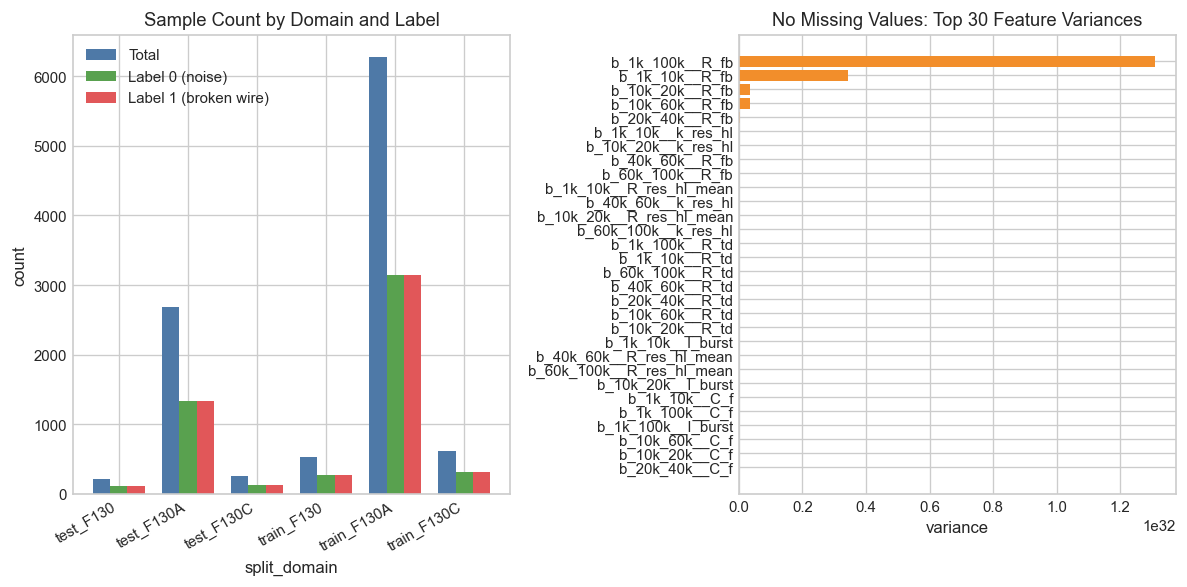

In [30]:
# 目的（Purpose）: 可视化数据集构成（dataset composition）与基础数据质量指标（data-quality indicators）。
# 输入（Inputs）: 上一节生成的 `summary_counts`、`view_df`，以及 `loaded_table.feature_columns`。
# 输出（Outputs）: 展示一个两联图（2-panel figure）：左侧为按域/标签计数，右侧为缺失率或方差排名。
# 副作用（Side effects）: 在 notebook 输出区渲染 matplotlib 图形（render plots）。
# 说明（Notes / Assumptions）: 若所有特征缺失率都为 0，则右图自动切换为特征方差（feature variance），保证图形仍有信息量。

# 图 1：按 split_domain 展示总样本数与各标签计数。
# 图 2：缺失率最高的特征 Top30（若缺失率全为 0，则回退为展示方差 Top30）。

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_counts = summary_counts.copy()
plot_counts['split_domain'] = plot_counts['split'] + '_' + plot_counts['base_domain']

x = np.arange(len(plot_counts))
bar_w = 0.25

total_vals = plot_counts['count'].to_numpy(dtype=float)
label0_vals = plot_counts.get('label_0_count', pd.Series(0, index=plot_counts.index)).to_numpy(dtype=float)
label1_vals = plot_counts.get('label_1_count', pd.Series(0, index=plot_counts.index)).to_numpy(dtype=float)

axes[0].bar(x - bar_w, total_vals, width=bar_w, label='Total', color='#4e79a7')
axes[0].bar(x, label0_vals, width=bar_w, label='Label 0 (noise)', color='#59a14f')
axes[0].bar(x + bar_w, label1_vals, width=bar_w, label='Label 1 (broken wire)', color='#e15759')
axes[0].set_title('Sample Count by Domain and Label')
axes[0].set_xlabel('split_domain')
axes[0].set_ylabel('count')
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_counts['split_domain'], rotation=30, ha='right')
axes[0].legend()

feature_cols = list(loaded_table.feature_columns)
missing_rate = view_df.loc[:, feature_cols].isna().mean().sort_values(ascending=False)

if float(missing_rate.max()) > 0:
    top_missing = missing_rate.head(30)
    axes[1].barh(top_missing.index[::-1], top_missing.values[::-1], color='#76b7b2')
    axes[1].set_title('Top 30 Missing Rates')
    axes[1].set_xlabel('missing_rate')
else:
    # If missing rate is zero everywhere, show top feature variance instead.
    variance = view_df.loc[:, feature_cols].apply(pd.to_numeric, errors='coerce').var().sort_values(ascending=False).head(30)
    axes[1].barh(variance.index[::-1], variance.values[::-1], color='#f28e2b')
    axes[1].set_title('No Missing Values: Top 30 Feature Variances')
    axes[1].set_xlabel('variance')

plt.tight_layout()
plt.show()

# 2. 特征选择（Feature Selection）

本节展示跨工况实验（cross-condition experiments）使用的两阶段特征选择流程。

**流程概览（Pipeline overview）**
- **阶段A筛选（Stage-A filtering）**：为每个特征计算得分（例如互信息 mutual information + 稳定性 stability），并保留 Top-K（Top-K candidates）候选特征。
- **阶段B包装法（Stage-B wrapper selection）**：在阶段A候选集上运行 RFECV（Recursive Feature Elimination with Cross-Validation），得到更紧凑的最终特征子集。

**为什么重要（Why this matters）**
- 跨工况泛化（cross-condition generalization）通常更依赖稳健/稳定的特征，而不只是特征数量。
- 本节提供表格与图形，帮助你选择合适的 Top-K（Top-K）并检查 RFECV（RFECV）的选择行为。


## 2.1 Stage-A Feature Filtering (Top-K)

This section demonstrates Stage-A filtering on one selected training-domain group.

Top-K notes:
- Top-K keeps the first K candidate features ranked by score.
- We compute one full score table first, then slice multiple Top-K candidates.



In [33]:
# Purpose: compute Stage-A scores once and slice multiple Top-K candidates.
# Inputs: loaded_table, experiment_specs[selected_experiment_index], random_state, top_k_candidates.
# Outputs: stage_a_scores and stage_a_candidates.
# Notes: this cell does feature candidate preparation only; no model training.

# 构建实验规格列表，每个规格定义了一组训练域组合（train_domains），供后续选择和运行阶段A筛选使用
experiment_specs = build_experiment_specs() 

# 从 `experiment_specs` 中根据 `selected_experiment_index` 选择一个基础实验规格 `base_spec`，
# 该规格包含了一个训练域组合（train_domains）
base_spec = experiment_specs[selected_experiment_index] 

print('selected_experiment_index =', selected_experiment_index)
print('base_spec.name          =', base_spec.name)
print('base_spec.train_domains =', base_spec.train_domains)

# 根据选择的 `base_spec` 构建训练掩码 `base_train_mask`：仅选择训练集（split=='train'）且 base_domain 在训练域组合内的行
base_train_mask = (loaded_table.frame['split'] == 'train') & loaded_table.frame['base_domain'].isin(base_spec.train_domains)
# base_domain：从每一行的 folder_name（或 sample_name）里规范化推断出来的域标识（大写、去掉 _tr/_te/_train/_test 之类后缀等）

print('base_train_mask True count =', int(base_train_mask.sum()))
print('base_train_mask total      =', int(len(base_train_mask)))

# -----------------------------------------------------------------------------------------------------------------
# (1) Stage-A scoring：对所有特征仅计算一次得分/排序（不输入 top_k）
stage_a_scores = run_stage_a_filter(
    table=loaded_table,
    train_mask=base_train_mask,
    random_state=random_state,
 )
print('stage_a_scores shape   =', stage_a_scores.shape)
print('stage_a_scores columns =', list(stage_a_scores.columns))

# -----------------------------------------------------------------------------------------------------------------
# (2) Top-K slicing：从一次性得分表里截取不同 Top-K 的候选特征，并生成每个 Top-K 对应的 StageAResult
stage_a_views = []
stage_a = None
stage_a_df = None
selected_by_k = {}
for top_k in top_k_candidates:
    stage_a = slice_stage_a_scores(stage_a_scores, top_k=top_k)
    stage_a_df = stage_a.scores.copy()
    stage_a_df['top_k'] = top_k
    stage_a_views.append(stage_a_df)
    selected_by_k[int(top_k)] = list(stage_a.selected_features)
    print(f'top_k={top_k}: selected_features={len(stage_a.selected_features)}')

# ---------------------- 可选一致性检查（sanity check）：Top-60 是否是 Top-80/120 的前缀 ----------------------
if len(top_k_candidates) >= 2:
    ks_sorted = sorted(int(k) for k in top_k_candidates)
    k0 = ks_sorted[0]
    base_prefix = selected_by_k[k0]
    for k in ks_sorted[1:]:
        ok = selected_by_k[k][:len(base_prefix)] == base_prefix
        print(f'prefix_check: Top-{k0} == prefix of Top-{k} ? {ok}')

# -----------------------------------------------------------------------------------------------------------------
# (3) 合并为大表：便于后续绘图/对比
stage_a_all = pd.concat(stage_a_views, ignore_index=True)
print('stage_a_all shape =', stage_a_all.shape)
print('stage_a_all top_k counts:\n', stage_a_all['top_k'].value_counts().sort_index())

# 预览：按 Top-K 分组后，每组展示 score 最高的前10行（避免只看到最小 top_k 的一组）
preview = (
    stage_a_all.sort_values(['top_k', 'score'], ascending=[True, False])
    .groupby('top_k', group_keys=False)
    .head(10)
 )
display(preview)


selected_experiment_index = 6
base_spec.name          = exp_07_train_F130_F130A_F130C
base_spec.train_domains = ('F130', 'F130A', 'F130C')
base_train_mask True count = 7428
base_train_mask total      = 10586
stage_a_scores shape   = (560, 15)
stage_a_scores columns = ['feature', 'missing_rate', 'variance', 'abs_corr_label', 'mutual_info', 'mi_norm', 'stability', 'score', 'keep_missing', 'keep_variance', 'eligible', 'keep_corr', 'stage_a_rank', 'selected_stage_a', 'selected_stage_a_rank']
top_k=60: selected_features=60
top_k=80: selected_features=80
top_k=120: selected_features=120
prefix_check: Top-60 == prefix of Top-80 ? True
prefix_check: Top-60 == prefix of Top-120 ? True
stage_a_all shape = (1680, 16)
stage_a_all top_k counts:
 top_k
60     560
80     560
120    560
Name: count, dtype: int64


,feature,missing_rate,variance,abs_corr_label,mutual_info,mi_norm,stability,score,keep_missing,keep_variance,eligible,keep_corr,stage_a_rank,selected_stage_a,selected_stage_a_rank,top_k
0,b_1k_10k__SC_mean,0.0,2.785322e+06,0.949162,0.693125,1.000000,0.883639,0.965092,True,True,True,True,1.0,True,1.0,60
1,b_1k_10k__C_f,0.0,9.515219e+12,0.932676,0.678058,0.978198,0.926069,0.962560,True,True,True,True,2.0,True,2.0,60
2,b_1k_100k__epsilon_2x,0.0,7.209414e+00,0.823684,0.688133,0.992777,0.878913,0.958618,True,True,True,True,3.0,True,3.0,60
3,b_1k_100k__R_wp_ddad,0.0,6.266009e-06,0.178126,0.683334,0.985833,0.842565,0.942853,True,True,True,True,4.0,True,4.0,60
4,b_1k_100k__R_wp_dddd,0.0,5.189754e-06,0.169333,0.675197,0.974059,0.858496,0.939390,True,True,True,True,5.0,True,5.0,60
60,b_1k_100k__C_h,0.0,1.804977e+07,0.920305,0.685600,0.989112,0.820345,0.938482,True,True,True,False,NaN,False,NaN,60
5,b_1k_100k__R_wp_ddda,0.0,1.572716e-06,0.178829,0.654453,0.944043,0.905332,0.932429,True,True,True,True,6.0,True,6.0,60
6,b_1k_10k__R_high_res,0.0,1.057696e-03,0.912343,0.640063,0.923220,0.952598,0.932034,True,True,True,True,7.0,True,7.0,60
7,b_1k_10k__H_wp,0.0,1.347946e-01,0.704593,0.665731,0.960361,0.838240,0.923725,True,True,True,True,8.0,True,8.0,60
8,b_1k_100k__D_WPT,0.0,3.166335e-04,0.201711,0.661081,0.953634,0.851467,0.922984,True,True,True,True,9.0,True,9.0,60


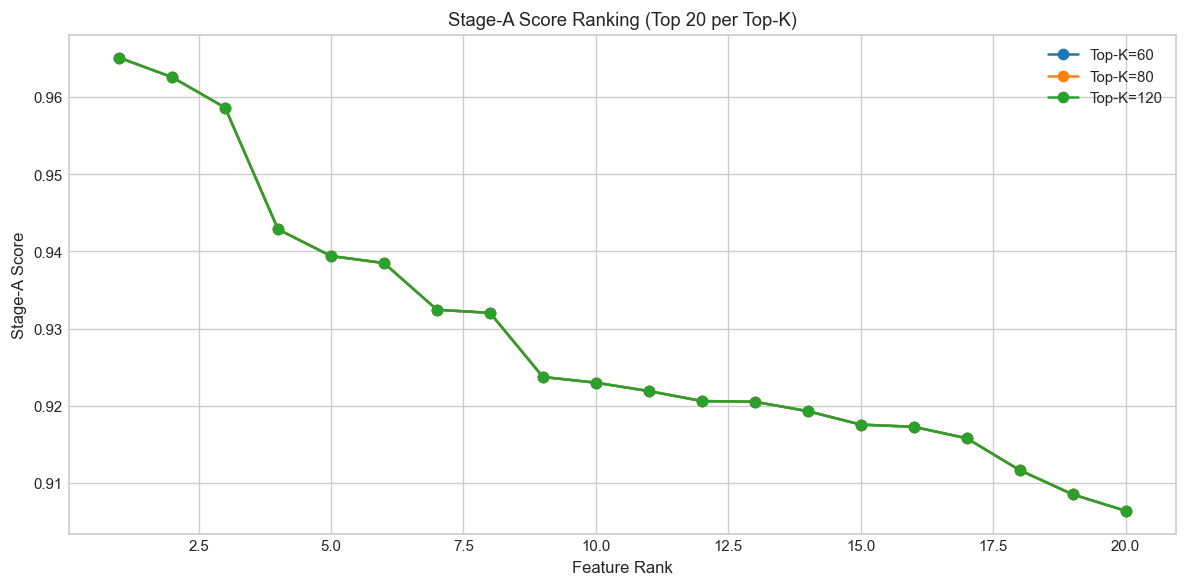

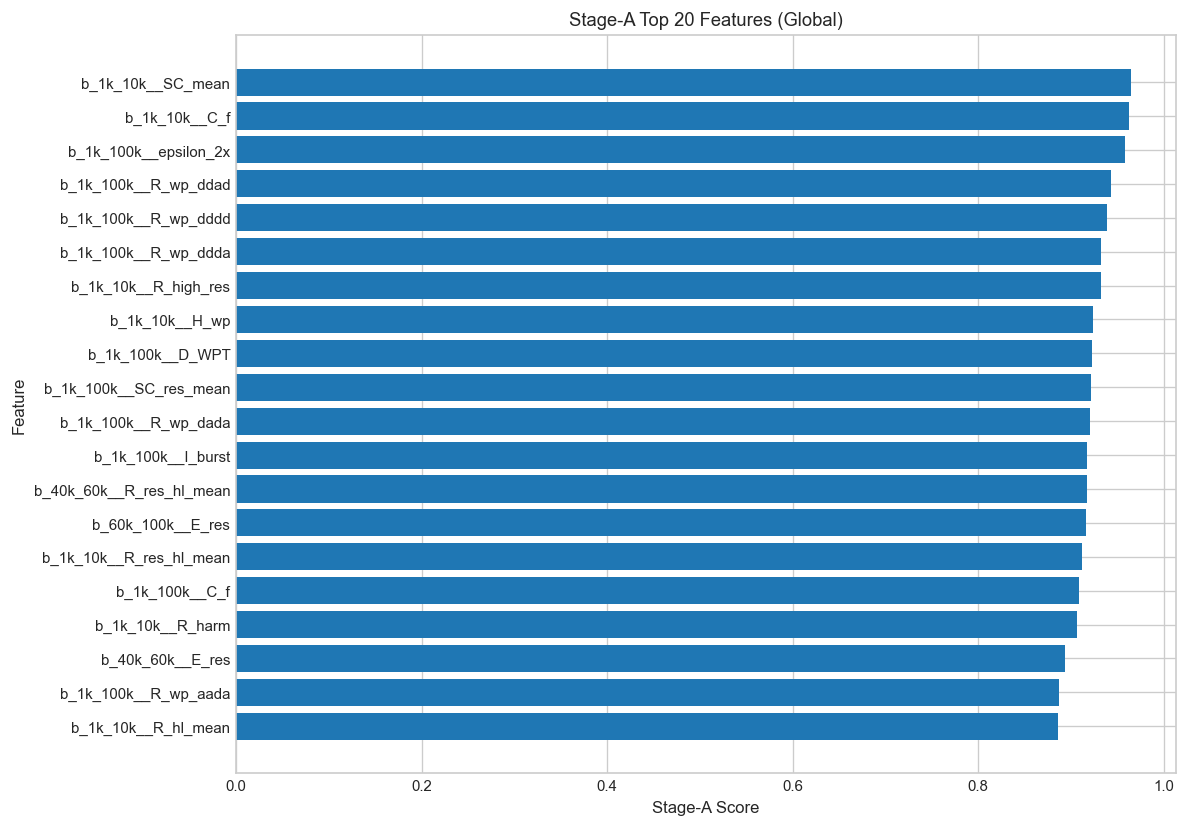

In [34]:
# 目的（Purpose）: 绘制阶段A得分衰减曲线（score decay curves），对比不同 Top-K 候选（Top-K candidates）。
# 输入（Inputs）: 上一单元格生成的 `stage_a_all`、`stage_a_scores`，以及 `top_k_candidates`。
# 输出（Outputs）:
#   1) “得分 vs 排名”的折线图（每个 Top-K 展示 Top20 特征）
#   2) 全局 Top20 特征得分柱状图（来自 stage_a_scores；x=score, y=feature name）
# 副作用（Side effects）: 在 notebook 输出区渲染 matplotlib 图形。
# 说明（Notes / Assumptions）: 图形仅用于诊断（diagnostic），不会直接改变选择结果。
# 详细目标（Detailed objective）:
# - 折线图：观察不同 Top-K 下得分衰减形状（score decay shape）。
# - 柱状图：直观看到分数最高的 Top20 特征及其分值。

# --- (A) Score-vs-rank curves (Top 20 per Top-K)
fig, ax = plt.subplots(figsize=(10, 5))

for top_k in top_k_candidates:
    sub = (
        stage_a_all.loc[stage_a_all['top_k'] == top_k]
        .sort_values('score', ascending=False)
        .head(20)
    )
    ax.plot(
        range(1, len(sub) + 1),
        sub['score'].to_numpy(),
        marker='o',
        label=f'Top-K={top_k}',
    )

ax.set_title('Stage-A Score Ranking (Top 20 per Top-K)')
ax.set_xlabel('Feature Rank')
ax.set_ylabel('Stage-A Score')
ax.legend()
plt.tight_layout()
plt.show()

# --- (B) Top-20 feature score bar chart (global, Top-K independent)
# 取 keep_corr==True 且 score 非空的特征，按 score 降序取 Top20
top20 = (
    stage_a_scores.loc[stage_a_scores['keep_corr'] & stage_a_scores['score'].notna(), ['feature', 'score']]
    .sort_values('score', ascending=False)
    .head(20)
    .copy()
)

# 反转顺序用于 barh：最高分显示在最上方/最下方都可以；这里让最高分在最上方（需要先 reverse）
top20_rev = top20.iloc[::-1]

fig2, ax2 = plt.subplots(figsize=(10, 7))
ax2.barh(top20_rev['feature'], top20_rev['score'])
ax2.set_title('Stage-A Top 20 Features (Global)')
ax2.set_xlabel('Stage-A Score')
ax2.set_ylabel('Feature')

# 特征名较长时，给左侧留出更多空间避免遮挡
fig2.tight_layout()
plt.show()

## 2.2 RFECV 包装法选择（RFECV Wrapper Selection）

在阶段A候选特征（Stage-A candidates）上运行 RFECV（Recursive Feature Elimination with Cross-Validation），并检查最终排序与入选情况。

**目的（Purpose）**
- 用包装法（wrapper method）在候选特征上做更精细的选择，得到更紧凑的最终特征子集（final feature subset）。
- 对比不同 Top-K（Top-K）下，最终入选特征数（selected feature count）与排名稳定性（ranking stability）的变化。

**输入（Inputs）**
- 对每个 `top_k`，先运行阶段A筛选（Stage-A filtering）得到候选特征。
- 训练掩码（training mask）由选定实验配置（experiment spec）确定。

**输出（Outputs）**
- `rfecv_all`：汇总表（summary table），包含排名（ranking）与最终是否入选（selected）。
- `rfecv_results`：从 `top_k` 到 RFECV 结果对象的映射（mapping），用于后续绘图。

**说明（Notes）**
- RFECV（RFECV）可能较耗时；调试时可减少 `top_k_candidates` 或先跑单个候选值。


In [ ]:
# 目的（Purpose）:（可选）在迭代开发（iterative development）时热重载 RFECV 包装模块（wrapper module）。
# 输入（Inputs）: 无。
# 输出（Outputs）: 重新导入并绑定最新代码版本的 `run_rfecv_selection`。
# 副作用（Side effects）: 在当前 kernel 会话中 reload `src.fea_sel_clasf.feature_wrapper` 模块。
# 说明（Notes / Assumptions）: 稳定运行（stable runs）可跳过；当你修改了 `feature_wrapper.py` 且不想重启 kernel 时很有用。
import importlib

import src.fea_sel_clasf.feature_wrapper as feature_wrapper

importlib.reload(feature_wrapper)
from src.fea_sel_clasf.feature_wrapper import run_rfecv_selection

In [ ]:
# 目的（Purpose）: 对每个阶段A的 Top-K 候选运行 RFECV（RFECV），并汇总为可比较的结果表。
# 输入（Inputs）: `loaded_table`、`base_train_mask`、`top_k_candidates`、`random_state`，以及（可选）`stage_a_scores`。
# 输出（Outputs）: `rfecv_all`（拼接后的汇总表 / concatenated summaries）与 `rfecv_results`（每个 Top-K 的结果对象）。
# 副作用（Side effects）: 在 notebook 输出区展示 RFECV 汇总表预览（display preview）。
# 说明（Notes / Assumptions）: Stage-A 得分（stage_a_scores）是 Top-K 无关的；只需计算一次，然后对不同 Top-K 做截取生成候选特征，避免重复运算。

# --- Stage-A scoring (Top-K independent)
if 'stage_a_scores' not in globals():
    stage_a_scores = run_stage_a_filter(
        table=loaded_table,
        train_mask=base_train_mask,
        random_state=random_state,
    )
print('stage_a_scores shape   =', stage_a_scores.shape)

# --- RFECV for each Top-K slice
rfecv_views = []
rfecv_results = {}
for top_k in top_k_candidates:
    stage_a = slice_stage_a_scores(stage_a_scores, top_k=top_k)
    print(f'top_k={top_k}: candidate_features={len(stage_a.selected_features)}')

    rfecv = run_rfecv_selection(
        table=loaded_table,
        train_mask=base_train_mask,
        candidate_features=stage_a.selected_features,
        random_state=random_state,
        scoring='f1',
    )
    rfecv_df = rfecv.summary.copy()
    rfecv_df['top_k'] = top_k
    rfecv_views.append(rfecv_df)
    rfecv_results[top_k] = rfecv
    if hasattr(rfecv, 'selected_features'):
        selected_names = list(rfecv.selected_features)
        print(f'  rfecv selected_features={len(selected_names)}')
        print(f'  rfecv selected_feature_names={selected_names}')

        # RFECV 内部用于评估“特征组合是否合适”的标准：交叉验证评分（scoring，默认 f1）。
        # 这里打印 RFECV 自动选择出的最佳特征数对应的 CV mean±std 分数。
        if getattr(rfecv, 'cv_best_mean_score', None) is not None:
            mean_score = float(rfecv.cv_best_mean_score)
            std_score = float(rfecv.cv_best_std_score) if rfecv.cv_best_std_score is not None else float('nan')
            best_n = int(rfecv.cv_best_n_features) if rfecv.cv_best_n_features is not None else len(selected_names)
            scoring_name = str(getattr(rfecv, 'cv_scoring', 'f1'))
            print(f'  rfecv_cv_best: scoring={scoring_name}, mean={mean_score:.4f}, std={std_score:.4f}, n_features={best_n}')
        else:
            print('  rfecv_cv_best: N/A (cv curve not available)')

rfecv_all = pd.concat(rfecv_views, ignore_index=True)
display(rfecv_all.head(30))

stage_a_scores shape   = (560, 15)
top_k=60: candidate_features=60
  rfecv selected_features=5
  rfecv selected_feature_names=['b_1k_10k__SC_mean', 'b_1k_10k__C_f', 'b_1k_100k__epsilon_2x', 'b_1k_10k__R_2_1', 'b_1k_10k__SC_res_mean']
  rfecv_cv_best: scoring=f1, mean=1.0000, std=0.0000, n_features=5
top_k=80: candidate_features=80
  rfecv selected_features=5
  rfecv selected_feature_names=['b_1k_10k__SC_mean', 'b_1k_10k__C_f', 'b_1k_10k__R_high_res', 'b_1k_100k__SC_mean', 'b_40k_60k__SC_mean']
  rfecv_cv_best: scoring=f1, mean=1.0000, std=0.0000, n_features=5
top_k=120: candidate_features=120
  rfecv selected_features=5
  rfecv selected_feature_names=['b_1k_10k__SC_mean', 'b_1k_10k__C_f', 'b_1k_100k__SC_mean', 'b_1k_10k__SC_res_mean', 'b_40k_60k__SC_mean']
  rfecv_cv_best: scoring=f1, mean=1.0000, std=0.0000, n_features=5


,feature,rfecv_support,rfecv_ranking,selected_final,top_k
0,b_1k_100k__epsilon_2x,True,1,True,60
1,b_1k_10k__C_f,True,1,True,60
2,b_1k_10k__R_2_1,True,1,True,60
3,b_1k_10k__SC_mean,True,1,True,60
4,b_1k_10k__SC_res_mean,True,1,True,60
5,b_1k_100k__SC_mean,False,2,False,60
6,b_1k_10k__C_h,False,3,False,60
7,b_1k_10k__R_high_res,False,4,False,60
8,b_10k_20k__H_stack,False,5,False,60
9,b_1k_100k__SC_res_mean,False,6,False,60


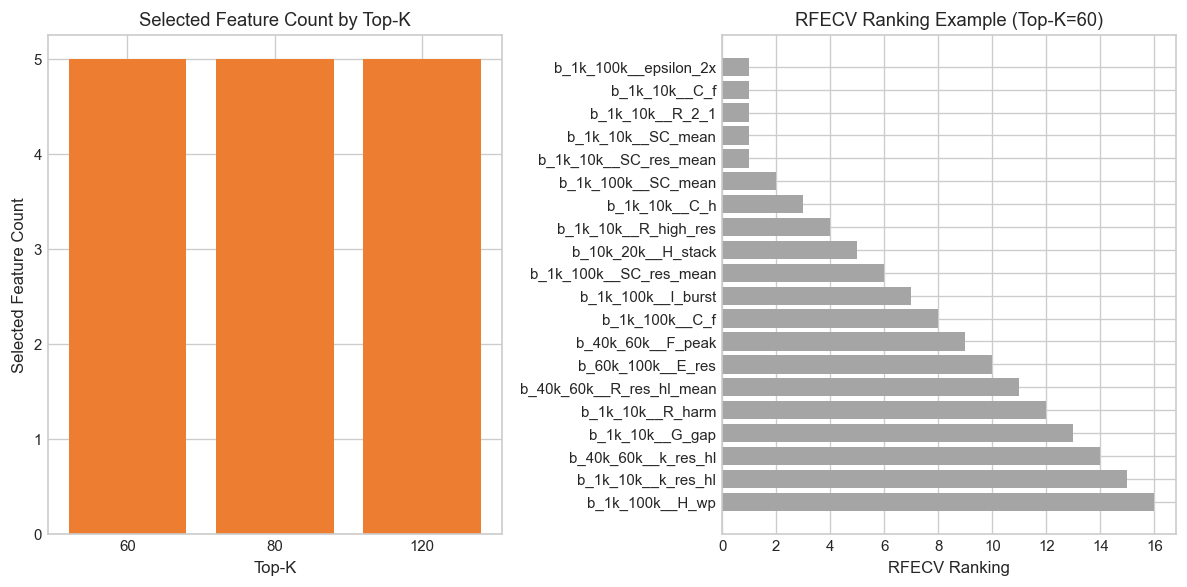

In [ ]:
# 目的（Purpose）: 可视化 RFECV 结果：比较不同 Top-K 下的入选特征数，并展示一个示例 Top-K 的排名列表（ranking list）。
# 输入（Inputs）: `rfecv_all`、`rfecv_results`、`top_k_candidates`。
# 输出（Outputs）: 一张两联图（2-panel figure）：左图为各 Top-K 的最终入选特征数；右图为某个 Top-K 的 RFECV 排名 Top-N。
# 副作用（Side effects）: 在 notebook 输出区渲染 matplotlib 图形。
# 说明（Notes / Assumptions）: 右图默认用 `top_k_candidates[0]` 作为示例；如需更换参考值可修改该索引。
# 详细目标（Detailed objective）:
# - 左图：对比不同 Top-K 候选的最终入选特征数量。
# - 右图：检查某个代表性 Top-K 下 RFECV 的排名行为（ranking behavior）。
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Count how many features survive RFECV for each Top-K candidate.
selected_counts = (
    rfecv_all.groupby('top_k', dropna=False)['selected_final']
    .sum()
    .reset_index(name='selected_count')
)

# Bar chart of selected feature counts.
axes[0].bar(selected_counts['top_k'].astype(str), selected_counts['selected_count'], color='#ed7d31')
axes[0].set_title('Selected Feature Count by Top-K')
axes[0].set_xlabel('Top-K')
axes[0].set_ylabel('Selected Feature Count')

# Use the first Top-K candidate as a concrete ranking example.
example_rfecv = rfecv_results[top_k_candidates[0]].summary.copy()
show_n = min(20, len(example_rfecv))

# Horizontal bars for RFECV rankings (smaller rank is better).
axes[1].barh(
    example_rfecv['feature'].head(show_n)[::-1],
    example_rfecv['rfecv_ranking'].head(show_n)[::-1],
    color='#a5a5a5'
)
axes[1].set_title(f'RFECV Ranking Example (Top-K={top_k_candidates[0]})')
axes[1].set_xlabel('RFECV Ranking')

plt.tight_layout()
plt.show()



## 2.3 特征数对比（Feature-Count Comparison）

对比不同特征数量（feature count）下的模型指标（model metrics）。

**目的（Purpose）**
- 量化“特征数（feature count）—性能（performance）”之间的权衡关系。
- 帮助判断更大的 Top-K（Top-K）是否值得（是否能显著提升指标）。

**输入（Inputs）**
- 与阶段A/RFECV 演示相同的训练掩码（training mask）与 `top_k_candidates`。
- `target_recall`：用于从 OOF（out-of-fold）预测中选择阈值（threshold）。

**输出（Outputs）**
- 对比表：每个 Top-K（Top-K）的最终特征数、交叉验证指标（CV metrics）与阈值（threshold）。
- 下一单元格绘制“特征数 vs 指标”的趋势图。


In [ ]:
# 目的（Purpose）: 对比不同特征数（feature count）下的端到端模型性能（end-to-end performance）。
# 输入（Inputs）: `loaded_table`、`base_train_mask`、`top_k_candidates`、`target_recall`、`random_state`。
# 输出（Outputs）: 生成 `comparison_df`，包含 Top-K、最终入选特征数、CV 指标（CV metrics）与所选概率阈值（threshold）。
# 副作用（Side effects）: 会执行模型搜索/训练（model search & training），并在 notebook 输出区展示结果表。
# 说明（Notes / Assumptions）: 阈值基于 OOF（out-of-fold）预测选择，以满足正类（断线 / broken wire）的 `target_recall`。
comparison_rows = []

# Stage-A scoring is Top-K independent → compute once, then slice per K.
stage_a_scores = run_stage_a_filter(
    table=loaded_table,
    train_mask=base_train_mask,
    random_state=random_state,
 )

for top_k in top_k_candidates:
    stage_a = slice_stage_a_scores(stage_a_scores, top_k=top_k)
    rfecv = run_rfecv_selection(
        table=loaded_table,
        train_mask=base_train_mask,
        candidate_features=stage_a.selected_features,
        random_state=random_state,
    )
    model = search_best_model(
        table=loaded_table,
        train_mask=base_train_mask,
        selected_features=rfecv.selected_features,
        random_state=random_state,
    )
    threshold = choose_threshold_from_oof(model.oof_label, model.oof_probability, target_recall=target_recall)
    comparison_rows.append(
        {
            'top_k': top_k,
            'selected_feature_count': len(rfecv.selected_features),
            'cv_mean_recall_pos': float(model.cv_results.iloc[0]['mean_recall_pos']),
            'cv_mean_balanced_accuracy': float(model.cv_results.iloc[0]['mean_balanced_accuracy']),
            'threshold': threshold.threshold,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)





KeyboardInterrupt: 

In [ ]:
# 目的（Purpose）: 可视化交叉验证指标（CV metrics）随最终入选特征数（selected feature count）的变化趋势。
# 输入（Inputs）: 上一单元格生成的 `comparison_df`。
# 输出（Outputs）: 一张折线图：横轴为入选特征数，纵轴为召回（recall）与平衡准确率（balanced accuracy）。
# 副作用（Side effects）: 在 notebook 输出区渲染 matplotlib 图形。
# 说明（Notes / Assumptions）: 本图使用 CV 均值；跨域泛化（cross-domain generalization）仍需以第 3 节的测试域结果（test-domain results）为准。
# 详细目标（Detailed objective）:
# - 将模型质量（model quality）与最终入选特征数建立直观对照。
# - 帮助判断继续增加特征是否仍能带来性能提升（performance gain）。
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot recall and balanced accuracy over selected feature count.
ax1.plot(
    comparison_df['selected_feature_count'],
    comparison_df['cv_mean_recall_pos'],
    marker='o',
    label='Recall_pos',
    color='#4472c4'
)
ax1.plot(
    comparison_df['selected_feature_count'],
    comparison_df['cv_mean_balanced_accuracy'],
    marker='s',
    label='Balanced_Accuracy',
    color='#70ad47'
)

# Label axes and title to make the trade-off explicit.
ax1.set_xlabel('Selected Feature Count')
ax1.set_ylabel('CV Score')
ax1.set_title('Feature Count vs CV Metrics')
ax1.legend()

plt.tight_layout()
plt.show()



## 2.4 不同数据集的特征提取结果对比（Cross-Dataset Feature Extraction Comparison）

本节把 2.1 和 2.2 的流程封装为可复用函数，并对 0~6 共 7 个数据集做统一对比。

**目的（Purpose）**
- 把 Stage-A 筛选（Stage-A filtering）+ RFECV（RFECV）抽象成一个函数，避免在不同数据集上重复写相同代码。
- 对比 7 个数据集在相同 Top-K（Top-K=60）下得到的最终特征组合（selected feature set）是否一致、重叠或存在明显差异。
- 提供图形化对比（visual comparison），帮助快速判断数据集之间的特征相似性。

**说明（Notes）**
- 本节默认沿用前面定义的 `loaded_table`、`build_experiment_specs()`、`run_stage_a_filter()` 和 `run_rfecv_selection()`。
- 如果你只想看结果，不需要修改任何算法逻辑，只需运行本节即可。


### 2.4.1 抽象为函数（Abstract 2.1 / 2.2 into a function）

本小节把 2.1 的 Stage-A 筛选和 2.2 的 RFECV 选择封装为一个函数，便于后面批量处理 7 个数据集。

**目的（Purpose）**
- 输入一个实验配置（ExperimentSpec），自动完成训练域掩码（train mask）、Top-K 候选筛选和 RFECV。
- 返回完整结果，包含候选特征、最终特征组合、CV 最优分数和中间表。

**输出（Outputs）**
- 一个结果字典（dict），可直接用于打印、表格汇总和画图。

**说明（Notes）**
- 这里固定保留 Top-K=60 作为本节对比标准，确保不同数据集之间的比较口径一致。


In [35]:
# 目的（Purpose）: 把 2.1 的 Stage-A 筛选与 2.2 的 RFECV 选择合并成一个可复用函数（reusable helper）。
# 输入（Inputs）: `table`、`spec`、`top_k`、`random_state`、`scoring`。
# 输出（Outputs）: 返回一个字典，包含 Stage-A 结果、RFECV 结果、最终特征名和关键 CV 诊断信息。
# 副作用（Side effects）: 会运行特征筛选与 RFECV；若上层代码打印结果，则会在 notebook 中输出文本。
# 说明（Notes / Assumptions）: 仅做流程抽象，不改变原有筛选逻辑；Top-K 默认固定为 60 以便跨数据集对比。
def run_stage_a_rfecv_for_spec(table, spec, top_k=60, random_state=42, scoring='f1'):
    """Run Stage-A filtering and RFECV for one experiment spec (单个数据集的 Stage-A + RFECV 流程).

    Summary
    - Builds the train mask from `spec.train_domains` and `split == 'train'`.
    - Runs Stage-A once, slices Top-K candidates, then applies RFECV on those candidates.
    - Returns both the selected feature names and the diagnostic scores used for comparison.

    Args
    - table: LoadedFeatureTable. Merged feature table used throughout the notebook.
    - spec: ExperimentSpec. Defines the training domains for one dataset/group.
    - top_k: int. Number of Stage-A candidate features to keep before RFECV.
    - random_state: int. Seed used by Stage-A and RFECV.
    - scoring: str. RFECV scoring metric; this notebook uses 'f1' by default.

    Returns
    - dict with keys: `spec`, `top_k`, `train_mask`, `stage_a_scores`, `stage_a`, `rfecv`,
      `selected_features`, `candidate_feature_count`, `selected_feature_count`, `cv_best_mean_score`,
      `cv_best_std_score`, `cv_best_n_features`, `cv_scoring`.

    Notes
    - The function is intentionally read-only with respect to inputs; it only computes results in memory.
    """
    train_mask = (table.frame['split'] == 'train') & table.frame['base_domain'].isin(spec.train_domains)
    if not bool(train_mask.any()):
        raise ValueError(f'No training rows found for {spec.name}')

    stage_a_scores = run_stage_a_filter(
        table=table,
        train_mask=train_mask,
        random_state=random_state,
    )
    stage_a = slice_stage_a_scores(stage_a_scores, top_k=top_k)
    rfecv = run_rfecv_selection(
        table=table,
        train_mask=train_mask,
        candidate_features=stage_a.selected_features,
        random_state=random_state,
        scoring=scoring,
    )

    selected_features = list(rfecv.selected_features)
    return {
        'spec': spec,
        'top_k': int(top_k),
        'train_mask': train_mask,
        'stage_a_scores': stage_a_scores,
        'stage_a': stage_a,
        'rfecv': rfecv,
        'selected_features': selected_features,
        'candidate_feature_count': int(len(stage_a.selected_features)),
        'selected_feature_count': int(len(selected_features)),
        'cv_best_mean_score': getattr(rfecv, 'cv_best_mean_score', None),
        'cv_best_std_score': getattr(rfecv, 'cv_best_std_score', None),
        'cv_best_n_features': getattr(rfecv, 'cv_best_n_features', None),
        'cv_scoring': getattr(rfecv, 'cv_scoring', scoring),
    }

def _feature_signature(features):
    """Return a stable printable signature for a feature set (将特征集合转成稳定的可打印表示)."""
    return ' | '.join(features) if features else '(empty)'

### 2.4.2 七个数据集的特征组合对比（Seven-Dataset Feature Combination Comparison）

本小节对 0~6 共 7 个数据集统一执行 Top-K=60 的 Stage-A + RFECV，并打印最终特征组合的异同。

**目的（Purpose）**
- 对比不同数据集最终提取出的特征集合（selected feature sets）是否相同。
- 找出 7 个数据集共有的特征（common features）以及各自独有的特征（unique features）。
- 用图形直观表达对比结果，回答“是否可以通过图直观表述”：可以，下面给出频数条形图和 Jaccard 相似度热力图。

**输出（Outputs）**
- 每个数据集的最终特征列表（feature list）。
- 汇总表（summary table）。
- 两类图：特征数对比图、两两 Jaccard 相似度热力图。


[0] exp_01_train_F130
  train_domains=('F130',)
  test_domains=('F130', 'F130A', 'F130C')
  candidate_features=20
  selected_features=5
  selected_feature_names=['b_1k_10k__SC_mean', 'b_20k_40k__SC_mean', 'b_1k_100k__SC_res_mean', 'b_1k_100k__epsilon_2x', 'b_1k_10k__C_f']
  rfecv_cv_best: scoring=f1, mean=1.0000, std=0.0000, n_features=5
--------------------------------------------------------------------------------
[1] exp_02_train_F130A
  train_domains=('F130A',)
  test_domains=('F130', 'F130A', 'F130C')
  candidate_features=20
  selected_features=5
  selected_feature_names=['b_1k_10k__SC_mean', 'b_60k_100k__E_res', 'b_1k_10k__C_f', 'b_1k_100k__SC_mean', 'b_1k_100k__I_burst']
  rfecv_cv_best: scoring=f1, mean=1.0000, std=0.0000, n_features=5
--------------------------------------------------------------------------------
[2] exp_03_train_F130C
  train_domains=('F130C',)
  test_domains=('F130', 'F130A', 'F130C')
  candidate_features=20
  selected_features=5
  selected_feature_names=[

,dataset_index,experiment,train_domains,test_domains,candidate_feature_count,selected_feature_count,selected_features
0,0,exp_01_train_F130,F130,F130+F130A+F130C,20,5,b_1k_10k__SC_mean | b_20k_40k__SC_mean | b_1k_...
1,1,exp_02_train_F130A,F130A,F130+F130A+F130C,20,5,b_1k_10k__SC_mean | b_60k_100k__E_res | b_1k_1...
2,2,exp_03_train_F130C,F130C,F130+F130A+F130C,20,5,b_1k_10k__SC_mean | b_1k_100k__C_h | b_1k_10k_...
3,3,exp_04_train_F130_F130A,F130+F130A,F130+F130A+F130C,20,5,b_1k_10k__C_f | b_1k_100k__epsilon_2x | b_1k_1...
4,4,exp_05_train_F130_F130C,F130+F130C,F130+F130A+F130C,20,5,b_1k_10k__C_f | b_1k_10k__SC_mean | b_1k_100k_...
5,5,exp_06_train_F130A_F130C,F130A+F130C,F130+F130A+F130C,20,5,b_1k_10k__SC_mean | b_1k_100k__epsilon_2x | b_...
6,6,exp_07_train_F130_F130A_F130C,F130+F130A+F130C,F130+F130A+F130C,20,5,b_1k_10k__SC_mean | b_1k_10k__C_f | b_1k_100k_...


common_features = ['b_1k_10k__C_f', 'b_1k_10k__SC_mean']
exp_01_train_F130: unique_features=['b_20k_40k__SC_mean']
exp_02_train_F130A: unique_features=['b_60k_100k__E_res']
exp_03_train_F130C: unique_features=['b_1k_100k__C_h', 'b_1k_10k__rho_res']
exp_04_train_F130_F130A: unique_features=[]
exp_05_train_F130_F130C: unique_features=['b_1k_100k__C_f']
exp_06_train_F130A_F130C: unique_features=['b_1k_10k__R_high_res']
exp_07_train_F130_F130A_F130C: unique_features=[]


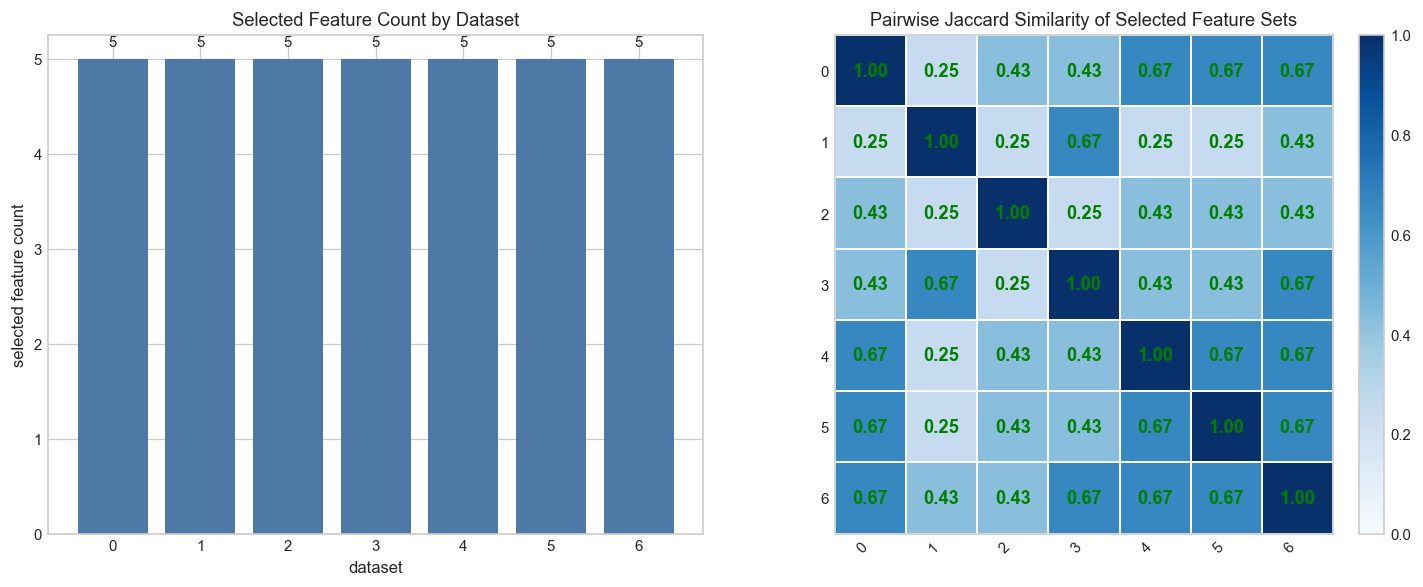

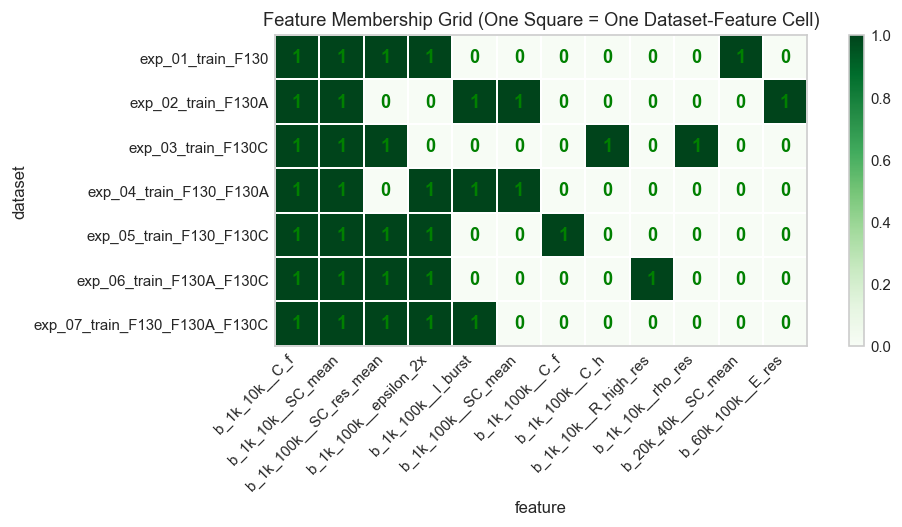

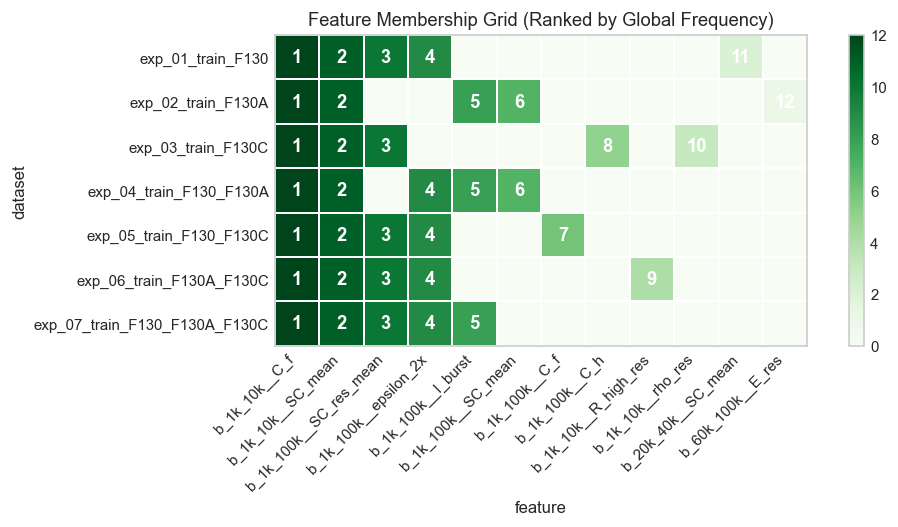

In [36]:
# 目的（Purpose）: 对 0~6 共 7 个数据集统一运行 Top-K=60 的 Stage-A + RFECV，并打印最终特征组合对比。
# 输入（Inputs）: `loaded_table`、`build_experiment_specs()`、`random_state`。
# 输出（Outputs）: `dataset_feature_results`、`dataset_feature_summary`、以及两张图（特征数条形图 + Jaccard 热力图）。
# 副作用（Side effects）: 会对 7 个数据集逐个执行筛选与 RFECV；在 notebook 输出区展示表格和图形。
# 说明（Notes / Assumptions）: 本节只比较“特征组合”本身，不改变训练/测试划分与模型评估逻辑。
dataset_specs = build_experiment_specs()
dataset_feature_results = []

for idx, spec in enumerate(dataset_specs):
    bundle = run_stage_a_rfecv_for_spec(
        table=loaded_table,
        spec=spec,
        top_k=20,
        random_state=random_state,
        scoring='f1',
    )
    dataset_feature_results.append(bundle)
    print(f'[{idx}] {spec.name}')
    print(f'  train_domains={spec.train_domains}')
    print(f'  test_domains={spec.test_domains}')
    print(f'  candidate_features={bundle["candidate_feature_count"]}')
    print(f'  selected_features={bundle["selected_feature_count"]}')
    print(f'  selected_feature_names={bundle["selected_features"]}')
    if bundle['cv_best_mean_score'] is not None:
        mean_score = float(bundle['cv_best_mean_score'])
        std_score = float(bundle['cv_best_std_score']) if bundle['cv_best_std_score'] is not None else float('nan')
        best_n = int(bundle['cv_best_n_features']) if bundle['cv_best_n_features'] is not None else bundle['selected_feature_count']
        scoring_name = str(bundle['cv_scoring'])
        print(f'  rfecv_cv_best: scoring={scoring_name}, mean={mean_score:.4f}, std={std_score:.4f}, n_features={best_n}')
    print('-' * 80)

dataset_feature_summary = pd.DataFrame([
    {
        'dataset_index': idx,
        'experiment': item['spec'].name,
        'train_domains': '+'.join(item['spec'].train_domains),
        'test_domains': '+'.join(item['spec'].test_domains),
        'candidate_feature_count': item['candidate_feature_count'],
        'selected_feature_count': item['selected_feature_count'],
        'selected_features': _feature_signature(item['selected_features']),
    }
    for idx, item in enumerate(dataset_feature_results)
])
display(dataset_feature_summary)

feature_sets = [set(item['selected_features']) for item in dataset_feature_results]
dataset_names = [item['spec'].name for item in dataset_feature_results]

if feature_sets:
    common_features = set.intersection(*feature_sets) if all(feature_sets) else set()
    union_features = set().union(*feature_sets)
    print('common_features =', sorted(common_features))
    for name, current in zip(dataset_names, feature_sets):
        others = set().union(*[s for s in feature_sets if s is not current]) if len(feature_sets) > 1 else set()
        unique_features = sorted(current - others)
        print(f'{name}: unique_features={unique_features}')

    # Pairwise Jaccard similarity matrix: J(A, B) = |A ∩ B| / |A ∪ B|
    n = len(feature_sets)
    jaccard = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            a, b = feature_sets[i], feature_sets[j]
            denom = len(a | b)
            jaccard[i, j] = 1.0 if denom == 0 else len(a & b) / denom

    # Figure 1: selected feature count by dataset
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    counts = [len(s) for s in feature_sets]
    x = np.arange(len(dataset_names))
    axes[0].bar(x, counts, color='#4e79a7')
    axes[0].set_title('Selected Feature Count by Dataset')
    axes[0].set_xlabel('dataset')
    axes[0].set_ylabel('selected feature count')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([str(i) for i in range(len(dataset_names))], rotation=0)
    for xi, yi in zip(x, counts):
        axes[0].text(xi, yi + 0.1, str(yi), ha='center', va='bottom', fontsize=9)

    # Figure 2: pairwise Jaccard similarity heatmap with square cells and centered annotations.
    jaccard_values = jaccard
    j_rows, j_cols = jaccard_values.shape
    j_x_edges = np.arange(j_cols + 1)
    j_y_edges = np.arange(j_rows + 1)
    im = axes[1].pcolormesh(j_x_edges, j_y_edges, jaccard_values, cmap='Blues', vmin=0, vmax=1, shading='flat', edgecolors='white', linewidth=1.0)
    axes[1].set_aspect('equal')
    axes[1].set_title('Pairwise Jaccard Similarity of Selected Feature Sets')
    axes[1].set_xticks(np.arange(n) + 0.5)
    axes[1].set_yticks(np.arange(n) + 0.5)
    axes[1].set_xticklabels([str(i) for i in range(n)], rotation=45, ha='right')
    axes[1].set_yticklabels([str(i) for i in range(n)])
    axes[1].invert_yaxis()
    for i in range(n):
        for j in range(n):
            axes[1].text(j + 0.5, i + 0.5, f'{jaccard_values[i, j]:.2f}', ha='center', va='center', color='green', fontsize=11, fontweight='bold')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # Optional Figure 3: binary membership heatmap for top frequent features (直观展示每个数据集是否选中该特征)
    freq = pd.Series(sorted(union_features)).map(lambda feat: sum(feat in s for s in feature_sets))
    top_features = [feat for feat, _ in sorted(zip(sorted(union_features), freq), key=lambda item: (-item[1], item[0]))][:30]
    if top_features:
        membership = pd.DataFrame(
            [[1 if feat in s else 0 for feat in top_features] for s in feature_sets],
            index=dataset_names,
            columns=top_features,
        )
        membership_values = membership.to_numpy(dtype=float)
        n_rows, n_cols = membership_values.shape
        fig2_width = max(10, 0.55 * n_cols)
        fig2_height = max(4.5, 0.55 * n_rows)
        fig2, ax2 = plt.subplots(figsize=(fig2_width, fig2_height))
        x_edges = np.arange(n_cols + 1)
        y_edges = np.arange(n_rows + 1)
        im2 = ax2.pcolormesh(x_edges, y_edges, membership_values, cmap='Greens', vmin=0, vmax=1, shading='flat', edgecolors='white', linewidth=1.0)
        ax2.set_aspect('equal')
        ax2.set_title('Feature Membership Grid (One Square = One Dataset-Feature Cell)')
        ax2.set_xlabel('feature')
        ax2.set_ylabel('dataset')
        ax2.set_xticks(np.arange(n_cols) + 0.5)
        ax2.set_yticks(np.arange(n_rows) + 0.5)
        ax2.set_xticklabels(top_features, rotation=45, ha='right')
        ax2.set_yticklabels(dataset_names)
        ax2.invert_yaxis()
        for i in range(n_rows):
            for j in range(n_cols):
                ax2.text(j + 0.5, i + 0.5, int(membership_values[i, j]), ha='center', va='center', color='green', fontsize=11, fontweight='bold')
        fig2.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

        # Figure 4: ranked membership grid (smaller rank = darker color).
        rank_lookup = {feature: rank for rank, feature in enumerate(top_features, start=1)}
        ranked_values = np.zeros((n_rows, n_cols), dtype=float)
        ranked_labels = np.full((n_rows, n_cols), '', dtype=object)
        max_rank = float(len(top_features)) if top_features else 1.0
        for i, current_features in enumerate(feature_sets):
            for j, feature in enumerate(top_features):
                if feature in current_features:
                    rank = rank_lookup[feature]
                    ranked_labels[i, j] = str(rank)
                    ranked_values[i, j] = max_rank - rank + 1.0
        fig3_width = max(10, 0.55 * n_cols)
        fig3_height = max(4.5, 0.55 * n_rows)
        fig3, ax3 = plt.subplots(figsize=(fig3_width, fig3_height))
        im3 = ax3.pcolormesh(x_edges, y_edges, ranked_values, cmap='Greens', vmin=0, vmax=max_rank, shading='flat', edgecolors='white', linewidth=1.0)
        ax3.set_aspect('equal')
        ax3.set_title('Feature Membership Grid (Ranked by Global Frequency)')
        ax3.set_xlabel('feature')
        ax3.set_ylabel('dataset')
        ax3.set_xticks(np.arange(n_cols) + 0.5)
        ax3.set_yticks(np.arange(n_rows) + 0.5)
        ax3.set_xticklabels(top_features, rotation=45, ha='right')
        ax3.set_yticklabels(dataset_names)
        ax3.invert_yaxis()
        for i in range(n_rows):
            for j in range(n_cols):
                if ranked_labels[i, j]:
                    ax3.text(j + 0.5, i + 0.5, ranked_labels[i, j], ha='center', va='center', color='white', fontsize=11, fontweight='bold')
        fig3.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()
else:
    print('No selected features were produced; heatmap not available.')

# 3. 七组实验执行（Seven-Group Experiment Execution）

本节按照预定义的 7 组训练域组合（seven training-domain groups）运行完整的跨工况评估协议（cross-condition protocol）。

> 在本 notebook 中，每个“组”对应一个 `ExperimentSpec`，其定义了 `train_domains` 与 `test_domains`。

**目的（Purpose）**
- 对每组执行完整流程：阶段A筛选（Stage-A filtering）→ RFECV（RFECV）→ 模型搜索（model search）→ 袋外阈值（OOF threshold）→ 按测试域评估（per-test-domain evaluation）。
- 将关键产物落盘（persist artifacts），便于审计（auditability）与复现（reproducibility）。

**输入（Inputs）**
- `experiment_specs = build_experiment_specs()`（在前面单元格中构建）。
- 第 1.1 节参数：路径、`top_k_candidates`、`target_recall`、`random_state`、`run_mode`。

**输出 / 产物（Outputs / artifacts）**
- 每个组在 `output_root/<spec.name>/` 下生成对应的 CSV/JSON 结果文件（详见第 3.1 节）。
- Notebook 内展示每组的汇总表与可视化图，用于快速检查。


## 3.1 单组实验运行函数（Single-Experiment Runner Function）

本节定义工具函数 `run_one_experiment(...)`，用于运行单个实验组（one experiment group）。

**目的（Purpose）**
- 将单组实验的全流程封装为一个函数，保证 7 组实验遵循同一协议（same protocol）。
- 统一管理落盘导出（artifact exporting），使每次运行可追踪（traceable）。

**输入（Inputs）**
- `spec`：实验配置（ExperimentSpec），定义训练域/测试域。
- 合并后的特征表 `loaded_table`，以及全局参数（Top-K、目标召回、随机种子、CPU/GPU 模式）。

**输出（Outputs）**
- 返回一个字典（dict），包含最终选择的 bundle（Stage-A、RFECV、model、threshold）与按测试域的汇总表（summary dataframe）。
- 写入 `output_root/` 下的每组实验目录（per-experiment folder），包含 CSV/JSON 产物。

**说明（Notes）**
- 该函数会导出较多中间结果，便于论文式报告与调试（debugging）。


In [37]:
# Purpose: define a unified function to run one cross-condition experiment group end-to-end.
# Inputs: spec, table, output_root, selected_features(optional), top_k_candidates, target_recall, random_state, run_mode.
# Outputs: result dict in memory + artifacts on disk under output_root/spec.name.
# Side effects: trains models and writes logs/models/metrics/readme files.
# Notes: if selected_features is provided (from section 2.4), Stage-A/RFECV are skipped.
def run_one_experiment(
    spec,
    table,
    output_root,
    top_k_candidates=(60, 80, 120),
    target_recall=0.95,
    random_state=42,
    run_mode='cpu',
    selected_features=None,
):
    """Run one cross-condition experiment group and persist artifacts."""
    import json
    from datetime import datetime
    from joblib import dump
    from sklearn.base import clone
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline

    from src.fea_sel_clasf.model_zoo import build_candidate_models

    train_mask = (table.frame['split'] == 'train') & table.frame['base_domain'].isin(spec.train_domains)
    if not bool(train_mask.any()):
        raise ValueError(f'No training rows found for {spec.name}')

    exp_dir = output_root / spec.name
    exp_dir.mkdir(parents=True, exist_ok=True)
    models_dir = exp_dir / 'models'
    logs_dir = exp_dir / 'logs'
    models_dir.mkdir(parents=True, exist_ok=True)
    logs_dir.mkdir(parents=True, exist_ok=True)

    # Feature selection source:
    # - selected_features is provided: use section 2.4 features directly.
    # - otherwise: run Stage-A + RFECV and select best Top-K bundle.
    stage_a = None
    rfecv = None
    best_top_k = None

    if selected_features is None:
        stage_a_scores = run_stage_a_filter(
            table=table,
            train_mask=train_mask,
            random_state=random_state,
        )

        candidate_rows = []
        best = None
        for top_k in top_k_candidates:
            stage_a_k = slice_stage_a_scores(stage_a_scores, top_k=top_k)
            rfecv_k = run_rfecv_selection(
                table=table,
                train_mask=train_mask,
                candidate_features=stage_a_k.selected_features,
                random_state=random_state,
            )
            model_k = search_best_model(
                table=table,
                train_mask=train_mask,
                selected_features=rfecv_k.selected_features,
                random_state=random_state,
                run_mode=run_mode,
            )
            threshold_k = choose_threshold_from_oof(model_k.oof_label, model_k.oof_probability, target_recall=target_recall)
            key = (
                float(model_k.cv_results.iloc[0]['mean_recall_pos']),
                float(model_k.cv_results.iloc[0]['mean_balanced_accuracy']),
                -float(model_k.cv_results.iloc[0]['std_recall_pos']),
                -float(model_k.cv_results.iloc[0]['std_balanced_accuracy']),
            )
            candidate_rows.append({
                'experiment': spec.name,
                'top_k': int(top_k),
                'model_name': model_k.model_name,
                'selected_feature_count': int(len(rfecv_k.selected_features)),
                'run_mode': run_mode,
                'cv_mean_recall_pos': float(model_k.cv_results.iloc[0]['mean_recall_pos']),
                'cv_mean_balanced_accuracy': float(model_k.cv_results.iloc[0]['mean_balanced_accuracy']),
                'threshold': float(threshold_k.threshold),
                'threshold_method': threshold_k.method,
                'feature_source': 'stage_a_rfecv_in_section_3_2',
            })
            if best is None or key > best['key']:
                best = {
                    'key': key,
                    'top_k': int(top_k),
                    'stage_a': stage_a_k,
                    'rfecv': rfecv_k,
                    'model': model_k,
                    'threshold': threshold_k,
                }

        if best is None:
            raise RuntimeError(f'No candidate bundle selected for {spec.name}')

        stage_a = best['stage_a']
        rfecv = best['rfecv']
        best_top_k = best['top_k']
        selected_features_final = list(rfecv.selected_features)

        candidate_df = pd.DataFrame(candidate_rows)
        candidate_df.to_csv(exp_dir / 'model_candidates.csv', index=False, encoding='utf-8-sig')
        stage_a.scores.to_csv(exp_dir / 'feature_scores.csv', index=False, encoding='utf-8-sig')
        rfecv.summary.to_csv(exp_dir / 'rfecv_summary.csv', index=False, encoding='utf-8-sig')
    else:
        selected_features_final = list(selected_features)
        if not selected_features_final:
            raise ValueError(f'selected_features is empty for {spec.name}')
        candidate_df = pd.DataFrame([
            {
                'experiment': spec.name,
                'top_k': None,
                'model_name': 'to_be_selected_after_model_search',
                'selected_feature_count': int(len(selected_features_final)),
                'run_mode': run_mode,
                'cv_mean_recall_pos': None,
                'cv_mean_balanced_accuracy': None,
                'threshold': None,
                'threshold_method': None,
                'feature_source': 'section_2_4_selected_features',
            }
        ])
        candidate_df.to_csv(exp_dir / 'model_candidates.csv', index=False, encoding='utf-8-sig')

    pd.DataFrame({'feature': selected_features_final}).to_csv(exp_dir / 'selected_features.csv', index=False, encoding='utf-8-sig')

    # Unified model search once on selected feature set.
    model_best = search_best_model(
        table=table,
        train_mask=train_mask,
        selected_features=selected_features_final,
        random_state=random_state,
        run_mode=run_mode,
    )
    threshold_best = choose_threshold_from_oof(model_best.oof_label, model_best.oof_probability, target_recall=target_recall)

    wanted_models = ['logistic_regression', 'rbf_svm', 'random_forest']
    all_specs = build_candidate_models(random_state=random_state, run_mode=run_mode)
    spec_map = {m.name: m for m in all_specs}

    train_frame = table.frame.loc[train_mask].copy()
    x_train = train_frame.loc[:, selected_features_final].apply(pd.to_numeric, errors='coerce')
    if not x_train.empty:
        x_train = x_train.copy()
        x_train.loc[:, x_train.isna().all()] = 0.0
    y_train = train_frame[table.label_column].to_numpy(dtype=int)

    model_records = []
    trained_models = {}
    cv_all = model_best.cv_results.copy()

    for model_name in wanted_models:
        if model_name not in spec_map:
            continue
        model_rows = cv_all.loc[cv_all['model_name'] == model_name].copy()
        if model_rows.empty:
            continue
        model_rows = model_rows.sort_values(
            ['mean_recall_pos', 'mean_balanced_accuracy', 'std_recall_pos', 'std_balanced_accuracy'],
            ascending=[False, False, True, True],
        ).reset_index(drop=True)
        row0 = model_rows.iloc[0]
        best_params = dict(row0['params'])

        clf = spec_map[model_name].builder(random_state)
        pipe = Pipeline(
            steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier', clone(clf)),
            ]
        )
        pipe.set_params(**best_params)
        pipe.fit(x_train, y_train)

        threshold_value = float(threshold_best.threshold)
        trained_models[model_name] = {'pipeline': pipe, 'threshold': threshold_value, 'params': best_params}

        model_records.append({
            'experiment': spec.name,
            'model_name': model_name,
            'top_k': best_top_k,
            'selected_feature_count': int(len(selected_features_final)),
            'threshold': threshold_value,
            'params': json.dumps(best_params, ensure_ascii=False),
            'run_mode': run_mode,
            'feature_source': 'section_2_4_selected_features' if selected_features is not None else 'stage_a_rfecv_in_section_3_2',
        })

        dump(pipe, models_dir / f'{model_name}.joblib')

    cv_all.to_csv(logs_dir / 'cv_model_search_full.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(model_records).to_csv(logs_dir / 'trained_models_summary.csv', index=False, encoding='utf-8-sig')

    eval_sets = {
        'F130': ['F130'],
        'F130A': ['F130A'],
        'F130C': ['F130C'],
        'F130+F130A+F130C': ['F130', 'F130A', 'F130C'],
    }

    metrics_rows = []
    for model_name, model_bundle in trained_models.items():
        pipe = model_bundle['pipeline']
        threshold_value = float(model_bundle['threshold'])

        for eval_name, domains in eval_sets.items():
            test_mask = (table.frame['split'] == 'test') & table.frame['base_domain'].isin(domains)
            if not bool(test_mask.any()):
                continue

            test_frame = table.frame.loc[test_mask].copy()
            x_test = test_frame.loc[:, selected_features_final].apply(pd.to_numeric, errors='coerce')
            y_test = test_frame[table.label_column].to_numpy(dtype=int)

            prob = pipe.predict_proba(x_test)[:, 1]
            metrics = evaluate_binary_predictions(y_test, prob, threshold_value)
            metrics.update({
                'experiment': spec.name,
                'model_name': model_name,
                'eval_set': eval_name,
                'eval_domains': '+'.join(domains),
                'train_domains': '+'.join(spec.train_domains),
                'top_k': best_top_k,
                'selected_feature_count': int(len(selected_features_final)),
                'run_mode': run_mode,
                'feature_source': 'section_2_4_selected_features' if selected_features is not None else 'stage_a_rfecv_in_section_3_2',
            })
            metrics_rows.append(metrics)

            (exp_dir / f'metrics_{model_name}_{eval_name}.json').write_text(
                json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8'
            )
            confusion_matrix_frame(y_test, prob, threshold_value).to_csv(
                exp_dir / f'confusion_matrix_{model_name}_{eval_name}.csv',
                encoding='utf-8-sig',
            )

    summary_df = pd.DataFrame(metrics_rows)
    summary_df.to_csv(exp_dir / 'summary.csv', index=False, encoding='utf-8-sig')

    run_manifest = {
        'experiment': spec.name,
        'train_domains': list(spec.train_domains),
        'fixed_eval_sets': eval_sets,
        'selected_top_k': best_top_k,
        'selected_features': selected_features_final,
        'trained_models': list(trained_models.keys()),
        'random_state': int(random_state),
        'run_mode': run_mode,
        'target_recall': float(target_recall),
        'feature_source': 'section_2_4_selected_features' if selected_features is not None else 'stage_a_rfecv_in_section_3_2',
        'generated_at': datetime.now().isoformat(timespec='seconds'),
    }
    (exp_dir / 'run_manifest.json').write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2), encoding='utf-8')

    readme_text = f"""Cross-condition experiment artifacts (spec={spec.name})

Feature source:
- {'section 2.4 selected_features (no re-selection in 3.2)' if selected_features is not None else 'selected inside 3.2 by Stage-A + RFECV'}

1) logs/
- cv_model_search_full.csv: full CV logs for all model/param candidates.
- trained_models_summary.csv: exported model summary (name/threshold/params).

2) models/
- logistic_regression.joblib
- rbf_svm.joblib
- random_forest.joblib

3) main files
- selected_features.csv: input feature vector for this experiment.
- summary.csv: metrics of 3 models on 4 eval sets.
- metrics_<model>_<eval_set>.json: per-model per-eval-set metrics.
- confusion_matrix_<model>_<eval_set>.csv: confusion matrix tables.
- run_manifest.json: key parameters for reproducibility.
"""
    (exp_dir / 'readme.txt').write_text(readme_text, encoding='utf-8')

    return {
        'spec': spec,
        'exp_dir': exp_dir,
        'candidate_df': candidate_df,
        'stage_a': stage_a,
        'rfecv': rfecv,
        'model': model_best,
        'threshold': threshold_best,
        'summary_df': summary_df,
        'best_top_k': best_top_k,
        'selected_features': selected_features_final,
    }



## 3.2 ????????Run Seven Experiment Groups?

???? 2.4 ?????? 7 ??????`dataset_feature_results` ?? `selected_features`?????????

???3.2 ?????? Stage-A / RFECV ???????? 2.4 ????????


In [38]:
top_k_candidates = (20,)

### 3.2.1 实验组 1（Experiment Group 1）

运行第 1 个实验配置（ExperimentSpec，spec index 0）。


In [39]:
# Build feature map from section 2.4 results: spec.name -> selected_features
if 'dataset_feature_results' not in globals():
    raise RuntimeError('dataset_feature_results not found. Run section 2.4 before section 3.2.')

features_by_spec = {item['spec'].name: list(item['selected_features']) for item in dataset_feature_results}
print('feature vectors loaded from section 2.4:', len(features_by_spec))
for k, v in features_by_spec.items():
    print(k, 'feature_count=', len(v))


feature vectors loaded from section 2.4: 7
exp_01_train_F130 feature_count= 5
exp_02_train_F130A feature_count= 5
exp_03_train_F130C feature_count= 5
exp_04_train_F130_F130A feature_count= 5
exp_05_train_F130_F130C feature_count= 5
exp_06_train_F130A_F130C feature_count= 5
exp_07_train_F130_F130A_F130C feature_count= 5


In [40]:
# 目的（Purpose）: 运行实验组 1（Experiment Group 1），并展示按测试域（test domain）的汇总指标（summary metrics）。
# 输入（Inputs）: `experiment_specs`、`loaded_table`，以及第 1.1 节的全局参数。
# 输出（Outputs）: 生成 `result_1`（包含 `summary_df`、最佳 bundle 与输出路径等）；打印 spec 名称并展示汇总表。
# 副作用（Side effects）: 会在 `output_root/spec_1.name/` 下写出产物（artifacts）；会训练模型，可能耗时。
# 说明（Notes / Assumptions）: 若仅调试可视化（plotting），可复用内存中的 `result_1` 而不重跑本单元格。
spec_1 = experiment_specs[0]
result_1 = run_one_experiment(
    spec=spec_1,
    table=loaded_table,
    output_root=output_root,
    top_k_candidates=top_k_candidates,
    target_recall=target_recall,
    random_state=random_state,
    run_mode=run_mode,
    selected_features=features_by_spec[spec_1.name],
)
print(result_1['spec'].name)
display(result_1['summary_df'])





exp_01_train_F130


,n_samples,accuracy,balanced_accuracy,recall_pos,precision_pos,specificity_neg,f1_pos,auroc,fpr,tp,...,threshold,experiment,model_name,eval_set,eval_domains,train_domains,top_k,selected_feature_count,run_mode,feature_source
0,218.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,0.0,109.0,...,0.920192,exp_01_train_F130,logistic_regression,F130,F130,F130,None,5,gpu,section_2_4_selected_features
1,2680.0,0.992910,0.992910,0.985821,1.0,1.0,0.992860,1.000000,0.0,1321.0,...,0.920192,exp_01_train_F130,logistic_regression,F130A,F130A,F130,None,5,gpu,section_2_4_selected_features
2,260.0,0.946154,0.946154,0.892308,1.0,1.0,0.943089,1.000000,0.0,116.0,...,0.920192,exp_01_train_F130,logistic_regression,F130C,F130C,F130,None,5,gpu,section_2_4_selected_features
3,3158.0,0.989550,0.989550,0.979101,1.0,1.0,0.989440,1.000000,0.0,1546.0,...,0.920192,exp_01_train_F130,logistic_regression,F130+F130A+F130C,F130+F130A+F130C,F130,None,5,gpu,section_2_4_selected_features
4,218.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,0.0,109.0,...,0.920192,exp_01_train_F130,rbf_svm,F130,F130,F130,None,5,gpu,section_2_4_selected_features
5,2680.0,0.996642,0.996642,0.993284,1.0,1.0,0.996630,1.000000,0.0,1331.0,...,0.920192,exp_01_train_F130,rbf_svm,F130A,F130A,F130,None,5,gpu,section_2_4_selected_features
6,260.0,0.965385,0.965385,0.930769,1.0,1.0,0.964143,1.000000,0.0,121.0,...,0.920192,exp_01_train_F130,rbf_svm,F130C,F130C,F130,None,5,gpu,section_2_4_selected_features
7,3158.0,0.994300,0.994300,0.988600,1.0,1.0,0.994268,1.000000,0.0,1561.0,...,0.920192,exp_01_train_F130,rbf_svm,F130+F130A+F130C,F130+F130A+F130C,F130,None,5,gpu,section_2_4_selected_features
8,218.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,0.0,109.0,...,0.920192,exp_01_train_F130,random_forest,F130,F130,F130,None,5,gpu,section_2_4_selected_features
9,2680.0,0.963060,0.963060,0.926119,1.0,1.0,0.961643,0.999994,0.0,1241.0,...,0.920192,exp_01_train_F130,random_forest,F130A,F130A,F130,None,5,gpu,section_2_4_selected_features


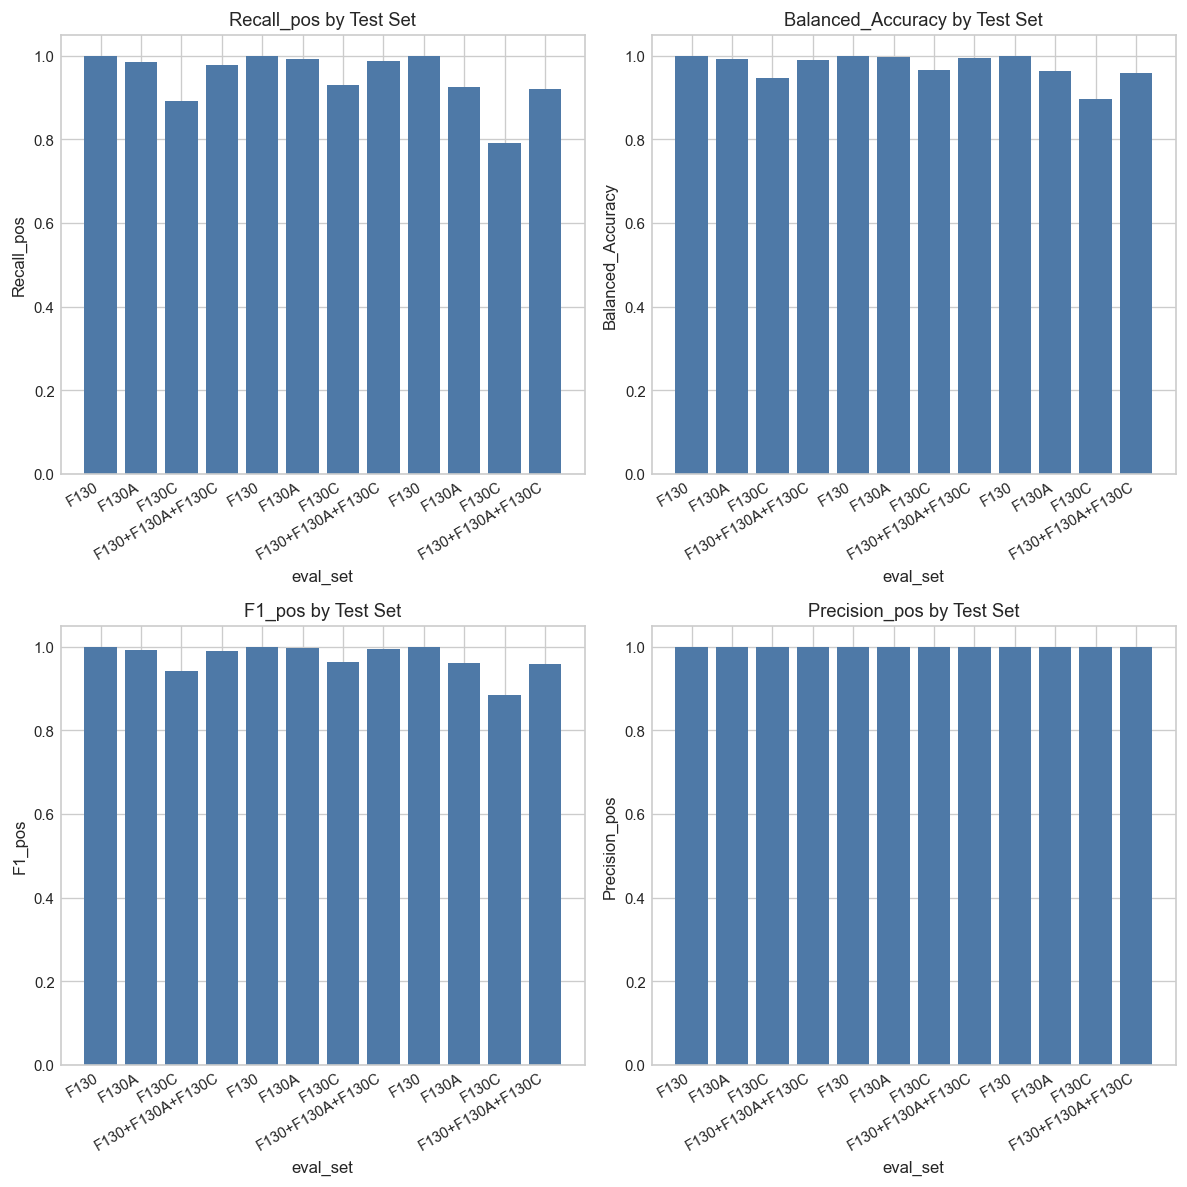

In [41]:
# Purpose: visualize per-group metrics with model-colored bars and legend.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_df = result_1['summary_df'].copy()

metric_map = [
    ('recall_pos', 'Recall_pos'),
    ('balanced_accuracy', 'Balanced_Accuracy'),
    ('f1_pos', 'F1_pos'),
    ('precision_pos', 'Precision_pos'),
]

label_col = 'eval_set' if 'eval_set' in plot_df.columns else ('test_domain' if 'test_domain' in plot_df.columns else None)
model_order = ['logistic_regression', 'rbf_svm', 'random_forest']

if not plot_df.empty and label_col is not None and 'model_name' in plot_df.columns:
    # index: test set, columns: model; each subplot keeps consistent colors by model and includes legend
    for ax, (col, title) in zip(axes.flatten(), metric_map):
        pv = plot_df.pivot_table(index=label_col, columns='model_name', values=col, aggfunc='mean')
        pv = pv.reindex(columns=[m for m in model_order if m in pv.columns])
        pv.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(f'{title} by Test Set')
        ax.set_xlabel(label_col)
        ax.set_ylabel(title)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=25)
        ax.legend(title='model', fontsize=8)
else:
    for ax in axes.flatten():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()



### 3.2.2 实验组 2（Experiment Group 2）

运行第 2 个实验配置（ExperimentSpec，spec index 1）。


In [42]:
# 目的（Purpose）: 运行实验组 2（Experiment Group 2），并展示按测试域（test domain）的汇总指标（summary metrics）。
# 输入（Inputs）: `experiment_specs`、`loaded_table`，以及第 1.1 节的全局参数。
# 输出（Outputs）: 生成 `result_2`；打印 spec 名称并展示 `summary_df`。
# 副作用（Side effects）: 会在 `output_root/spec_2.name/` 下写出产物（artifacts）；会训练模型，可能耗时。
# 说明（Notes / Assumptions）: 若 GPU 不可用，请在参数单元格将 `run_mode='cpu'` 后重新运行。
spec_2 = experiment_specs[1]
result_2 = run_one_experiment(
    spec=spec_2,
    table=loaded_table,
    output_root=output_root,
    top_k_candidates=top_k_candidates,
    target_recall=target_recall,
    random_state=random_state,
    run_mode=run_mode,
    selected_features=features_by_spec[spec_2.name],
)
print(result_2['spec'].name)
display(result_2['summary_df'])





exp_02_train_F130A


,n_samples,accuracy,balanced_accuracy,recall_pos,precision_pos,specificity_neg,f1_pos,auroc,fpr,tp,...,threshold,experiment,model_name,eval_set,eval_domains,train_domains,top_k,selected_feature_count,run_mode,feature_source
0,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,0.734606,exp_02_train_F130A,logistic_regression,F130,F130,F130A,None,5,gpu,section_2_4_selected_features
1,2680.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1340.0,...,0.734606,exp_02_train_F130A,logistic_regression,F130A,F130A,F130A,None,5,gpu,section_2_4_selected_features
2,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,0.734606,exp_02_train_F130A,logistic_regression,F130C,F130C,F130A,None,5,gpu,section_2_4_selected_features
3,3158.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1579.0,...,0.734606,exp_02_train_F130A,logistic_regression,F130+F130A+F130C,F130+F130A+F130C,F130A,None,5,gpu,section_2_4_selected_features
4,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,0.734606,exp_02_train_F130A,rbf_svm,F130,F130,F130A,None,5,gpu,section_2_4_selected_features
5,2680.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1340.0,...,0.734606,exp_02_train_F130A,rbf_svm,F130A,F130A,F130A,None,5,gpu,section_2_4_selected_features
6,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,0.734606,exp_02_train_F130A,rbf_svm,F130C,F130C,F130A,None,5,gpu,section_2_4_selected_features
7,3158.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1579.0,...,0.734606,exp_02_train_F130A,rbf_svm,F130+F130A+F130C,F130+F130A+F130C,F130A,None,5,gpu,section_2_4_selected_features
8,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,0.734606,exp_02_train_F130A,random_forest,F130,F130,F130A,None,5,gpu,section_2_4_selected_features
9,2680.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1340.0,...,0.734606,exp_02_train_F130A,random_forest,F130A,F130A,F130A,None,5,gpu,section_2_4_selected_features


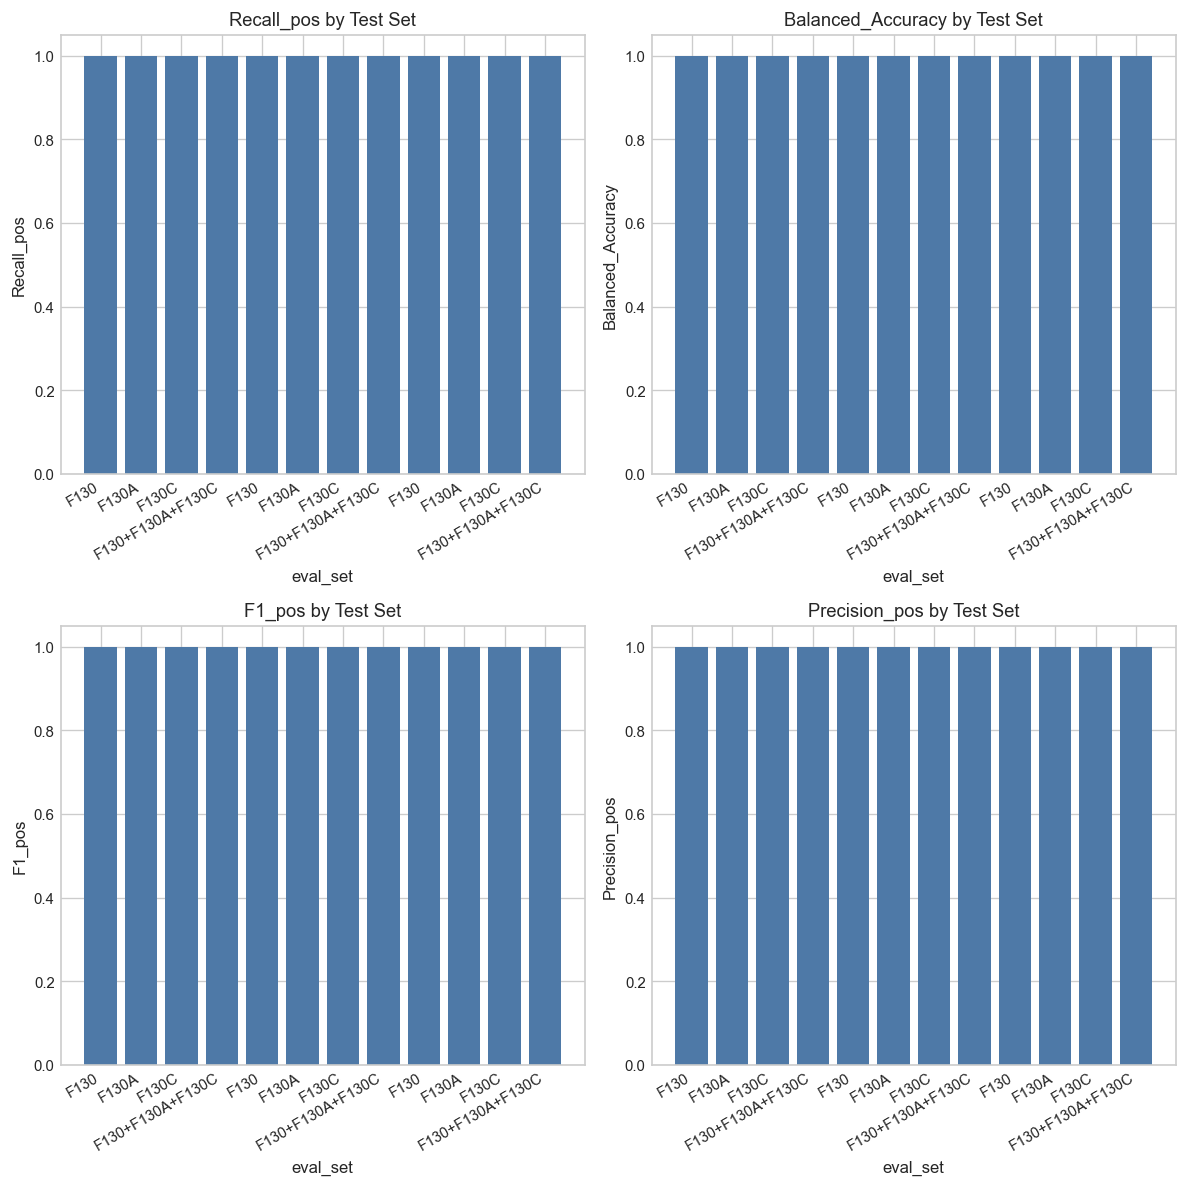

In [43]:
# Purpose: visualize per-group metrics with model-colored bars and legend.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_df = result_2['summary_df'].copy()

metric_map = [
    ('recall_pos', 'Recall_pos'),
    ('balanced_accuracy', 'Balanced_Accuracy'),
    ('f1_pos', 'F1_pos'),
    ('precision_pos', 'Precision_pos'),
]

label_col = 'eval_set' if 'eval_set' in plot_df.columns else ('test_domain' if 'test_domain' in plot_df.columns else None)
model_order = ['logistic_regression', 'rbf_svm', 'random_forest']

if not plot_df.empty and label_col is not None and 'model_name' in plot_df.columns:
    # index: test set, columns: model; each subplot keeps consistent colors by model and includes legend
    for ax, (col, title) in zip(axes.flatten(), metric_map):
        pv = plot_df.pivot_table(index=label_col, columns='model_name', values=col, aggfunc='mean')
        pv = pv.reindex(columns=[m for m in model_order if m in pv.columns])
        pv.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(f'{title} by Test Set')
        ax.set_xlabel(label_col)
        ax.set_ylabel(title)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=25)
        ax.legend(title='model', fontsize=8)
else:
    for ax in axes.flatten():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()



### 3.2.3 实验组 3（Experiment Group 3）

运行第 3 个实验配置（ExperimentSpec，spec index 2）。


In [44]:
# 目的（Purpose）: 运行实验组 3（Experiment Group 3），并展示按测试域（test domain）的汇总指标（summary metrics）。
# 输入（Inputs）: `experiment_specs`、`loaded_table`，以及第 1.1 节的全局参数。
# 输出（Outputs）: 生成 `result_3`；打印 spec 名称并展示 `summary_df`。
# 副作用（Side effects）: 会在 `output_root/spec_3.name/` 下写出产物（artifacts）；会训练模型，可能耗时。
# 说明（Notes / Assumptions）: 结果对 `random_state` 较敏感；跨组对比时建议保持固定（keep fixed）。
spec_3 = experiment_specs[2]
result_3 = run_one_experiment(
    spec=spec_3,
    table=loaded_table,
    output_root=output_root,
    top_k_candidates=top_k_candidates,
    target_recall=target_recall,
    random_state=random_state,
    run_mode=run_mode,
    selected_features=features_by_spec[spec_3.name],
)
print(result_3['spec'].name)
display(result_3['summary_df'])





exp_03_train_F130C


,n_samples,accuracy,balanced_accuracy,recall_pos,precision_pos,specificity_neg,f1_pos,auroc,fpr,tp,...,threshold,experiment,model_name,eval_set,eval_domains,train_domains,top_k,selected_feature_count,run_mode,feature_source
0,218.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,109.0,...,0.837927,exp_03_train_F130C,logistic_regression,F130,F130,F130C,None,5,gpu,section_2_4_selected_features
1,2680.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,1340.0,...,0.837927,exp_03_train_F130C,logistic_regression,F130A,F130A,F130C,None,5,gpu,section_2_4_selected_features
2,260.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,130.0,...,0.837927,exp_03_train_F130C,logistic_regression,F130C,F130C,F130C,None,5,gpu,section_2_4_selected_features
3,3158.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,1579.0,...,0.837927,exp_03_train_F130C,logistic_regression,F130+F130A+F130C,F130+F130A+F130C,F130C,None,5,gpu,section_2_4_selected_features
4,218.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,109.0,...,0.837927,exp_03_train_F130C,rbf_svm,F130,F130,F130C,None,5,gpu,section_2_4_selected_features
5,2680.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,1340.0,...,0.837927,exp_03_train_F130C,rbf_svm,F130A,F130A,F130C,None,5,gpu,section_2_4_selected_features
6,260.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,130.0,...,0.837927,exp_03_train_F130C,rbf_svm,F130C,F130C,F130C,None,5,gpu,section_2_4_selected_features
7,3158.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,1579.0,...,0.837927,exp_03_train_F130C,rbf_svm,F130+F130A+F130C,F130+F130A+F130C,F130C,None,5,gpu,section_2_4_selected_features
8,218.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,109.0,...,0.837927,exp_03_train_F130C,random_forest,F130,F130,F130C,None,5,gpu,section_2_4_selected_features
9,2680.0,0.998134,0.998134,0.996269,1.0,1.0,0.998131,1.0,0.0,1335.0,...,0.837927,exp_03_train_F130C,random_forest,F130A,F130A,F130C,None,5,gpu,section_2_4_selected_features


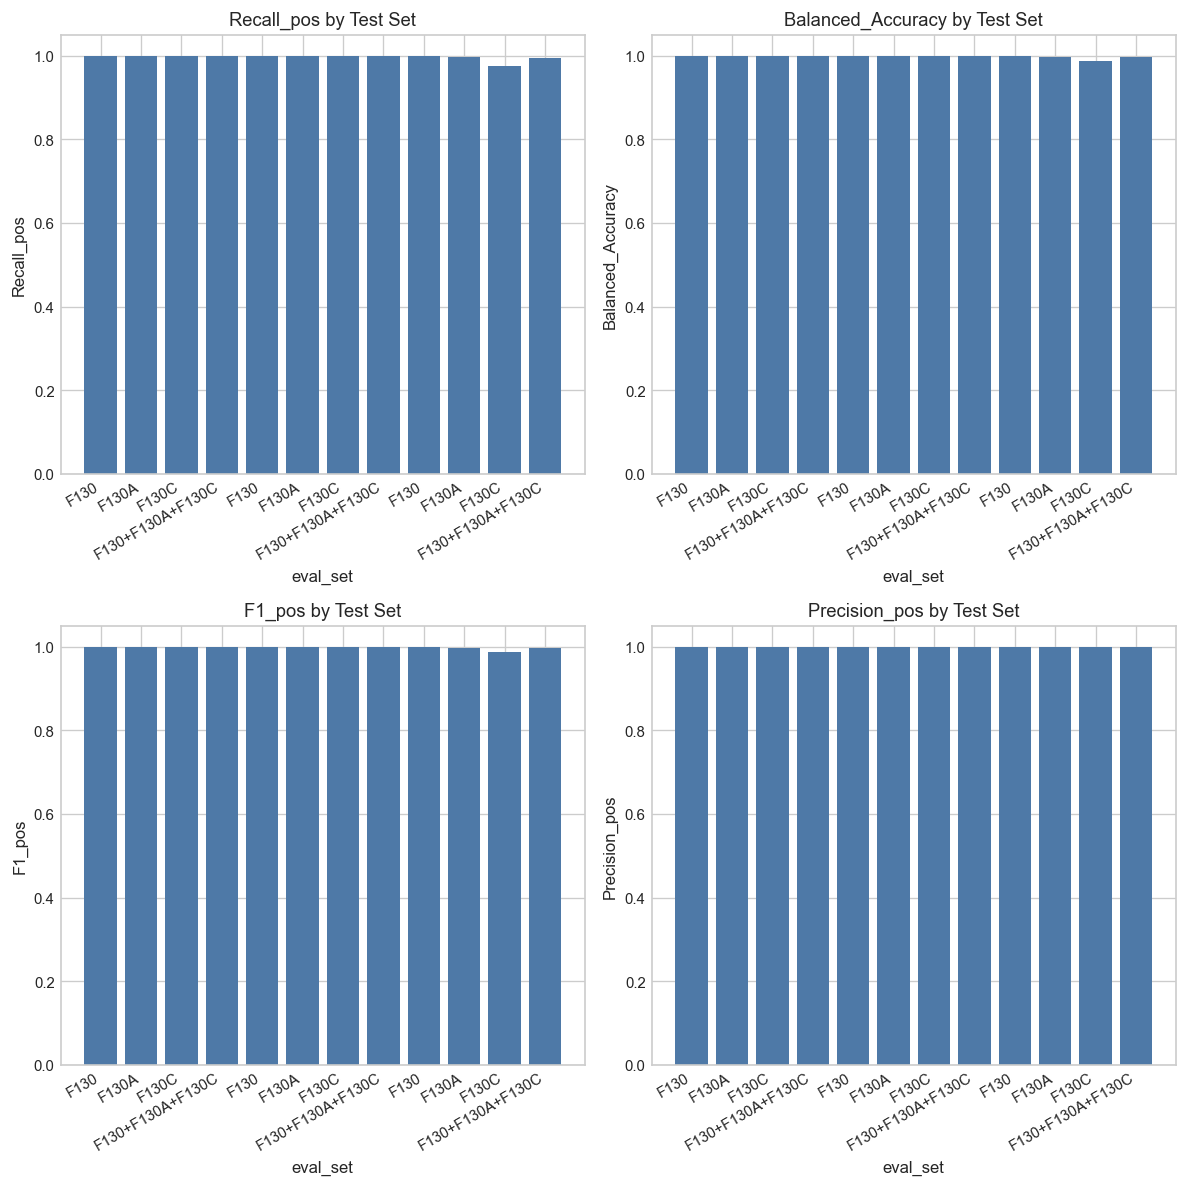

In [45]:
# Purpose: visualize per-group metrics with model-colored bars and legend.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_df = result_3['summary_df'].copy()

metric_map = [
    ('recall_pos', 'Recall_pos'),
    ('balanced_accuracy', 'Balanced_Accuracy'),
    ('f1_pos', 'F1_pos'),
    ('precision_pos', 'Precision_pos'),
]

label_col = 'eval_set' if 'eval_set' in plot_df.columns else ('test_domain' if 'test_domain' in plot_df.columns else None)
model_order = ['logistic_regression', 'rbf_svm', 'random_forest']

if not plot_df.empty and label_col is not None and 'model_name' in plot_df.columns:
    # index: test set, columns: model; each subplot keeps consistent colors by model and includes legend
    for ax, (col, title) in zip(axes.flatten(), metric_map):
        pv = plot_df.pivot_table(index=label_col, columns='model_name', values=col, aggfunc='mean')
        pv = pv.reindex(columns=[m for m in model_order if m in pv.columns])
        pv.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(f'{title} by Test Set')
        ax.set_xlabel(label_col)
        ax.set_ylabel(title)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=25)
        ax.legend(title='model', fontsize=8)
else:
    for ax in axes.flatten():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()



### 3.2.4 实验组 4（Experiment Group 4）

运行第 4 个实验配置（ExperimentSpec，spec index 3）。


In [46]:
# 目的（Purpose）: 运行实验组 4（Experiment Group 4），并展示按测试域（test domain）的汇总指标（summary metrics）。
# 输入（Inputs）: `experiment_specs`、`loaded_table`，以及第 1.1 节的全局参数。
# 输出（Outputs）: 生成 `result_4`；打印 spec 名称并展示 `summary_df`。
# 副作用（Side effects）: 会在 `output_root/spec_4.name/` 下写出产物（artifacts）；会训练模型，可能耗时。
# 说明（Notes / Assumptions）: 若希望更快迭代（faster iteration），可减少 `top_k_candidates` 或仅运行单个实验组。
spec_4 = experiment_specs[3]
result_4 = run_one_experiment(
    spec=spec_4,
    table=loaded_table,
    output_root=output_root,
    top_k_candidates=top_k_candidates,
    target_recall=target_recall,
    random_state=random_state,
    run_mode=run_mode,
    selected_features=features_by_spec[spec_4.name],
)
print(result_4['spec'].name)
display(result_4['summary_df'])





exp_04_train_F130_F130A


,n_samples,accuracy,balanced_accuracy,recall_pos,precision_pos,specificity_neg,f1_pos,auroc,fpr,tp,...,threshold,experiment,model_name,eval_set,eval_domains,train_domains,top_k,selected_feature_count,run_mode,feature_source
0,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,0.608433,exp_04_train_F130_F130A,logistic_regression,F130,F130,F130+F130A,None,5,gpu,section_2_4_selected_features
1,2680.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1340.0,...,0.608433,exp_04_train_F130_F130A,logistic_regression,F130A,F130A,F130+F130A,None,5,gpu,section_2_4_selected_features
2,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,0.608433,exp_04_train_F130_F130A,logistic_regression,F130C,F130C,F130+F130A,None,5,gpu,section_2_4_selected_features
3,3158.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1579.0,...,0.608433,exp_04_train_F130_F130A,logistic_regression,F130+F130A+F130C,F130+F130A+F130C,F130+F130A,None,5,gpu,section_2_4_selected_features
4,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,0.608433,exp_04_train_F130_F130A,rbf_svm,F130,F130,F130+F130A,None,5,gpu,section_2_4_selected_features
5,2680.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1340.0,...,0.608433,exp_04_train_F130_F130A,rbf_svm,F130A,F130A,F130+F130A,None,5,gpu,section_2_4_selected_features
6,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,0.608433,exp_04_train_F130_F130A,rbf_svm,F130C,F130C,F130+F130A,None,5,gpu,section_2_4_selected_features
7,3158.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1579.0,...,0.608433,exp_04_train_F130_F130A,rbf_svm,F130+F130A+F130C,F130+F130A+F130C,F130+F130A,None,5,gpu,section_2_4_selected_features
8,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,0.608433,exp_04_train_F130_F130A,random_forest,F130,F130,F130+F130A,None,5,gpu,section_2_4_selected_features
9,2680.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1340.0,...,0.608433,exp_04_train_F130_F130A,random_forest,F130A,F130A,F130+F130A,None,5,gpu,section_2_4_selected_features


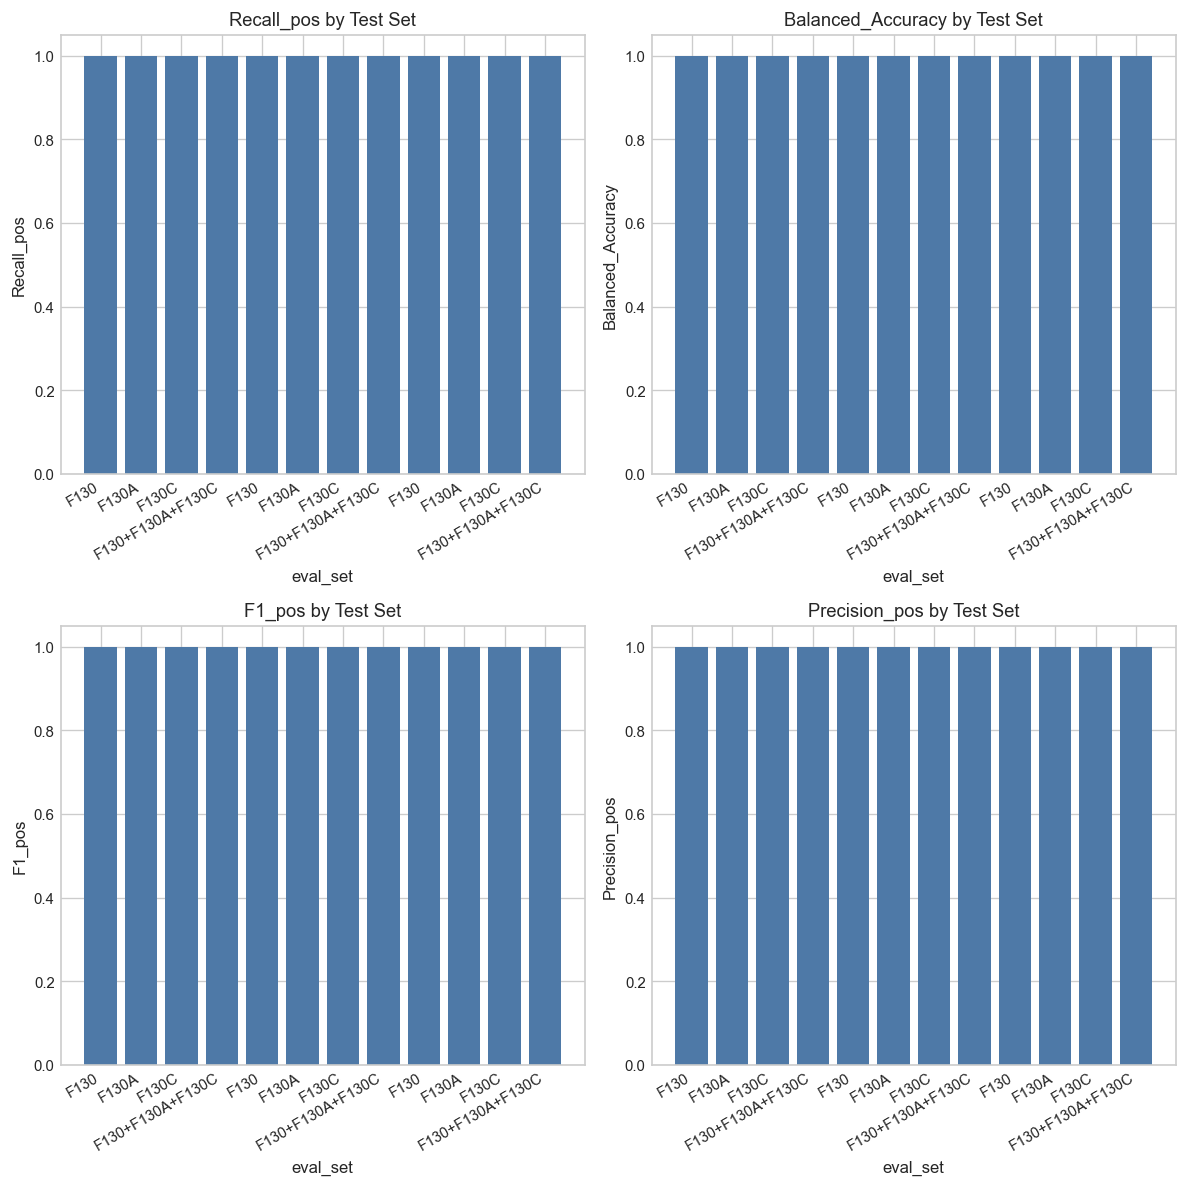

In [47]:
# Purpose: visualize per-group metrics with model-colored bars and legend.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_df = result_4['summary_df'].copy()

metric_map = [
    ('recall_pos', 'Recall_pos'),
    ('balanced_accuracy', 'Balanced_Accuracy'),
    ('f1_pos', 'F1_pos'),
    ('precision_pos', 'Precision_pos'),
]

label_col = 'eval_set' if 'eval_set' in plot_df.columns else ('test_domain' if 'test_domain' in plot_df.columns else None)
model_order = ['logistic_regression', 'rbf_svm', 'random_forest']

if not plot_df.empty and label_col is not None and 'model_name' in plot_df.columns:
    # index: test set, columns: model; each subplot keeps consistent colors by model and includes legend
    for ax, (col, title) in zip(axes.flatten(), metric_map):
        pv = plot_df.pivot_table(index=label_col, columns='model_name', values=col, aggfunc='mean')
        pv = pv.reindex(columns=[m for m in model_order if m in pv.columns])
        pv.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(f'{title} by Test Set')
        ax.set_xlabel(label_col)
        ax.set_ylabel(title)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=25)
        ax.legend(title='model', fontsize=8)
else:
    for ax in axes.flatten():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()



### 3.2.5 实验组 5（Experiment Group 5）

运行第 5 个实验配置（ExperimentSpec，spec index 4）。


In [48]:
# 目的（Purpose）: 运行实验组 5（Experiment Group 5），并展示按测试域（test domain）的汇总指标（summary metrics）。
# 输入（Inputs）: `experiment_specs`、`loaded_table`，以及第 1.1 节的全局参数。
# 输出（Outputs）: 生成 `result_5`；打印 spec 名称并展示 `summary_df`。
# 副作用（Side effects）: 会在 `output_root/spec_5.name/` 下写出产物（artifacts）；会训练模型，可能耗时。
# 说明（Notes / Assumptions）: 请确保 `output_root` 具备足够磁盘空间（disk space），每组会写出多份 CSV/JSON 文件。
spec_5 = experiment_specs[4]
result_5 = run_one_experiment(
    spec=spec_5,
    table=loaded_table,
    output_root=output_root,
    top_k_candidates=top_k_candidates,
    target_recall=target_recall,
    random_state=random_state,
    run_mode=run_mode,
    selected_features=features_by_spec[spec_5.name],
)
print(result_5['spec'].name)
display(result_5['summary_df'])





exp_05_train_F130_F130C


,n_samples,accuracy,balanced_accuracy,recall_pos,precision_pos,specificity_neg,f1_pos,auroc,fpr,tp,...,threshold,experiment,model_name,eval_set,eval_domains,train_domains,top_k,selected_feature_count,run_mode,feature_source
0,218.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,109.0,...,0.686848,exp_05_train_F130_F130C,logistic_regression,F130,F130,F130+F130C,None,5,gpu,section_2_4_selected_features
1,2680.0,0.999254,0.999254,0.998507,1.0,1.0,0.999253,1.0,0.0,1338.0,...,0.686848,exp_05_train_F130_F130C,logistic_regression,F130A,F130A,F130+F130C,None,5,gpu,section_2_4_selected_features
2,260.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,130.0,...,0.686848,exp_05_train_F130_F130C,logistic_regression,F130C,F130C,F130+F130C,None,5,gpu,section_2_4_selected_features
3,3158.0,0.999367,0.999367,0.998733,1.0,1.0,0.999366,1.0,0.0,1577.0,...,0.686848,exp_05_train_F130_F130C,logistic_regression,F130+F130A+F130C,F130+F130A+F130C,F130+F130C,None,5,gpu,section_2_4_selected_features
4,218.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,109.0,...,0.686848,exp_05_train_F130_F130C,rbf_svm,F130,F130,F130+F130C,None,5,gpu,section_2_4_selected_features
5,2680.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,1340.0,...,0.686848,exp_05_train_F130_F130C,rbf_svm,F130A,F130A,F130+F130C,None,5,gpu,section_2_4_selected_features
6,260.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,130.0,...,0.686848,exp_05_train_F130_F130C,rbf_svm,F130C,F130C,F130+F130C,None,5,gpu,section_2_4_selected_features
7,3158.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,1579.0,...,0.686848,exp_05_train_F130_F130C,rbf_svm,F130+F130A+F130C,F130+F130A+F130C,F130+F130C,None,5,gpu,section_2_4_selected_features
8,218.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,109.0,...,0.686848,exp_05_train_F130_F130C,random_forest,F130,F130,F130+F130C,None,5,gpu,section_2_4_selected_features
9,2680.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.0,1340.0,...,0.686848,exp_05_train_F130_F130C,random_forest,F130A,F130A,F130+F130C,None,5,gpu,section_2_4_selected_features


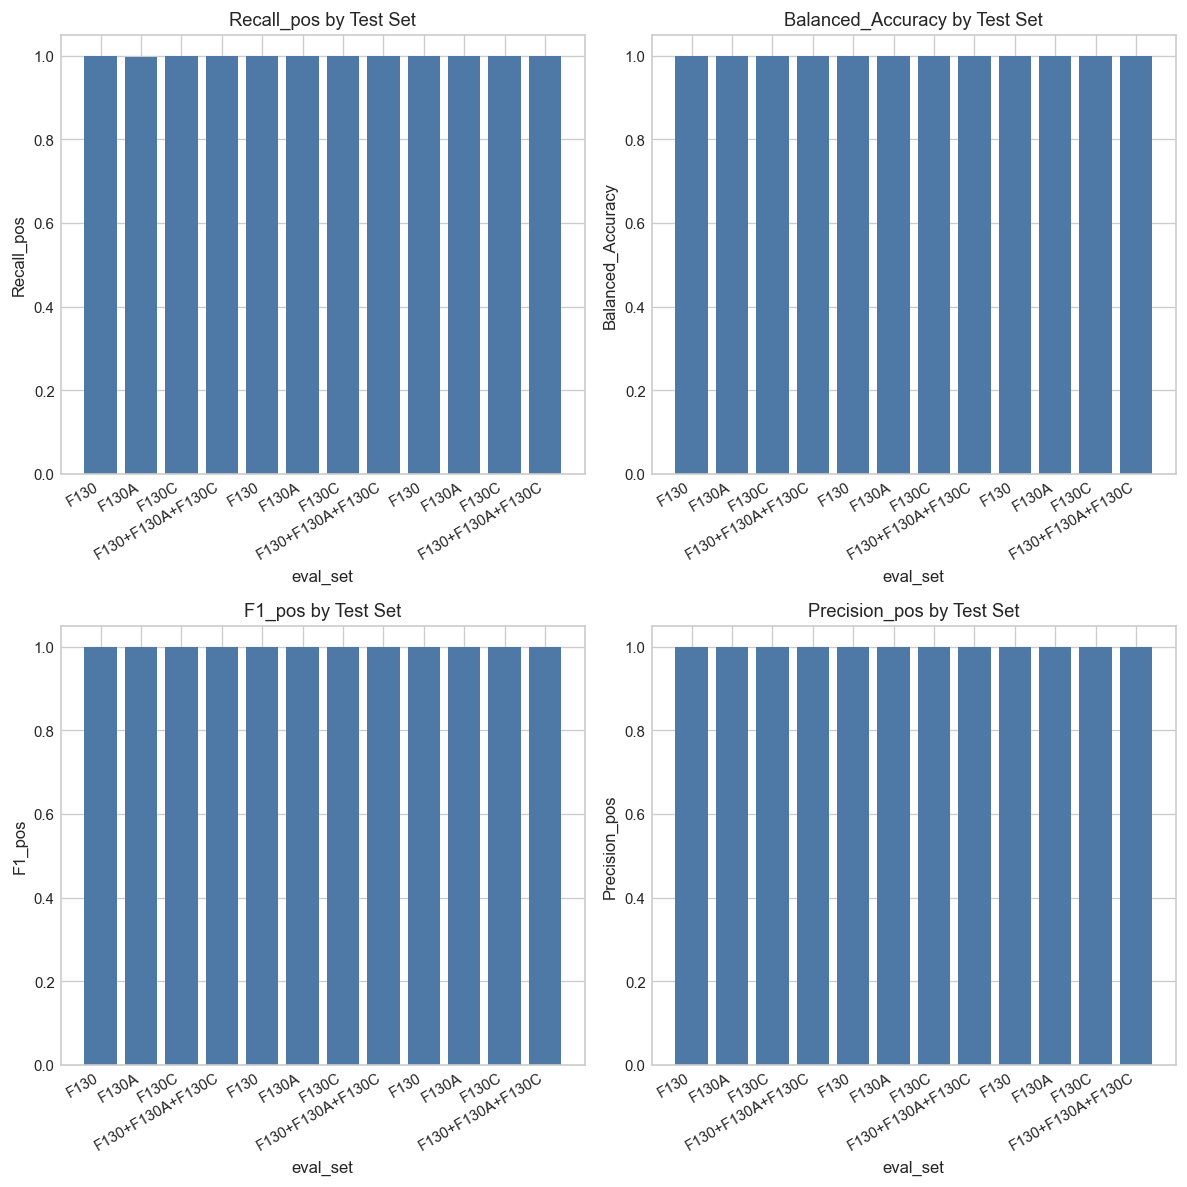

In [49]:
# Purpose: visualize per-group metrics with model-colored bars and legend.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_df = result_5['summary_df'].copy()

metric_map = [
    ('recall_pos', 'Recall_pos'),
    ('balanced_accuracy', 'Balanced_Accuracy'),
    ('f1_pos', 'F1_pos'),
    ('precision_pos', 'Precision_pos'),
]

label_col = 'eval_set' if 'eval_set' in plot_df.columns else ('test_domain' if 'test_domain' in plot_df.columns else None)
model_order = ['logistic_regression', 'rbf_svm', 'random_forest']

if not plot_df.empty and label_col is not None and 'model_name' in plot_df.columns:
    # index: test set, columns: model; each subplot keeps consistent colors by model and includes legend
    for ax, (col, title) in zip(axes.flatten(), metric_map):
        pv = plot_df.pivot_table(index=label_col, columns='model_name', values=col, aggfunc='mean')
        pv = pv.reindex(columns=[m for m in model_order if m in pv.columns])
        pv.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(f'{title} by Test Set')
        ax.set_xlabel(label_col)
        ax.set_ylabel(title)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=25)
        ax.legend(title='model', fontsize=8)
else:
    for ax in axes.flatten():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()



### 3.2.6 实验组 6（Experiment Group 6）

运行第 6 个实验配置（ExperimentSpec，spec index 5）。


In [50]:
# 目的（Purpose）: 运行实验组 6（Experiment Group 6），并展示按测试域（test domain）的汇总指标（summary metrics）。
# 输入（Inputs）: `experiment_specs`、`loaded_table`，以及第 1.1 节的全局参数。
# 输出（Outputs）: 生成 `result_6`；打印 spec 名称并展示 `summary_df`。
# 副作用（Side effects）: 会在 `output_root/spec_6.name/` 下写出产物（artifacts）；会训练模型，可能耗时。
# 说明（Notes / Assumptions）: 若 GPU 模式因环境（CUDA/XGBoost）缺失而失败，可切回 CPU（fall back to CPU）。
spec_6 = experiment_specs[5]
result_6 = run_one_experiment(
    spec=spec_6,
    table=loaded_table,
    output_root=output_root,
    top_k_candidates=top_k_candidates,
    target_recall=target_recall,
    random_state=random_state,
    run_mode=run_mode,
    selected_features=features_by_spec[spec_6.name],
)
print(result_6['spec'].name)
display(result_6['summary_df'])





exp_06_train_F130A_F130C


,n_samples,accuracy,balanced_accuracy,recall_pos,precision_pos,specificity_neg,f1_pos,auroc,fpr,tp,...,threshold,experiment,model_name,eval_set,eval_domains,train_domains,top_k,selected_feature_count,run_mode,feature_source
0,218.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,109.0,...,0.764023,exp_06_train_F130A_F130C,logistic_regression,F130,F130,F130A+F130C,None,5,gpu,section_2_4_selected_features
1,2680.0,0.999627,0.999627,1.0,0.999254,0.999254,0.999627,0.999919,0.000746,1340.0,...,0.764023,exp_06_train_F130A_F130C,logistic_regression,F130A,F130A,F130A+F130C,None,5,gpu,section_2_4_selected_features
2,260.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,130.0,...,0.764023,exp_06_train_F130A_F130C,logistic_regression,F130C,F130C,F130A+F130C,None,5,gpu,section_2_4_selected_features
3,3158.0,0.999683,0.999683,1.0,0.999367,0.999367,0.999683,0.999931,0.000633,1579.0,...,0.764023,exp_06_train_F130A_F130C,logistic_regression,F130+F130A+F130C,F130+F130A+F130C,F130A+F130C,None,5,gpu,section_2_4_selected_features
4,218.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,109.0,...,0.764023,exp_06_train_F130A_F130C,rbf_svm,F130,F130,F130A+F130C,None,5,gpu,section_2_4_selected_features
5,2680.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,1340.0,...,0.764023,exp_06_train_F130A_F130C,rbf_svm,F130A,F130A,F130A+F130C,None,5,gpu,section_2_4_selected_features
6,260.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,130.0,...,0.764023,exp_06_train_F130A_F130C,rbf_svm,F130C,F130C,F130A+F130C,None,5,gpu,section_2_4_selected_features
7,3158.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,1579.0,...,0.764023,exp_06_train_F130A_F130C,rbf_svm,F130+F130A+F130C,F130+F130A+F130C,F130A+F130C,None,5,gpu,section_2_4_selected_features
8,218.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,109.0,...,0.764023,exp_06_train_F130A_F130C,random_forest,F130,F130,F130A+F130C,None,5,gpu,section_2_4_selected_features
9,2680.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,1340.0,...,0.764023,exp_06_train_F130A_F130C,random_forest,F130A,F130A,F130A+F130C,None,5,gpu,section_2_4_selected_features


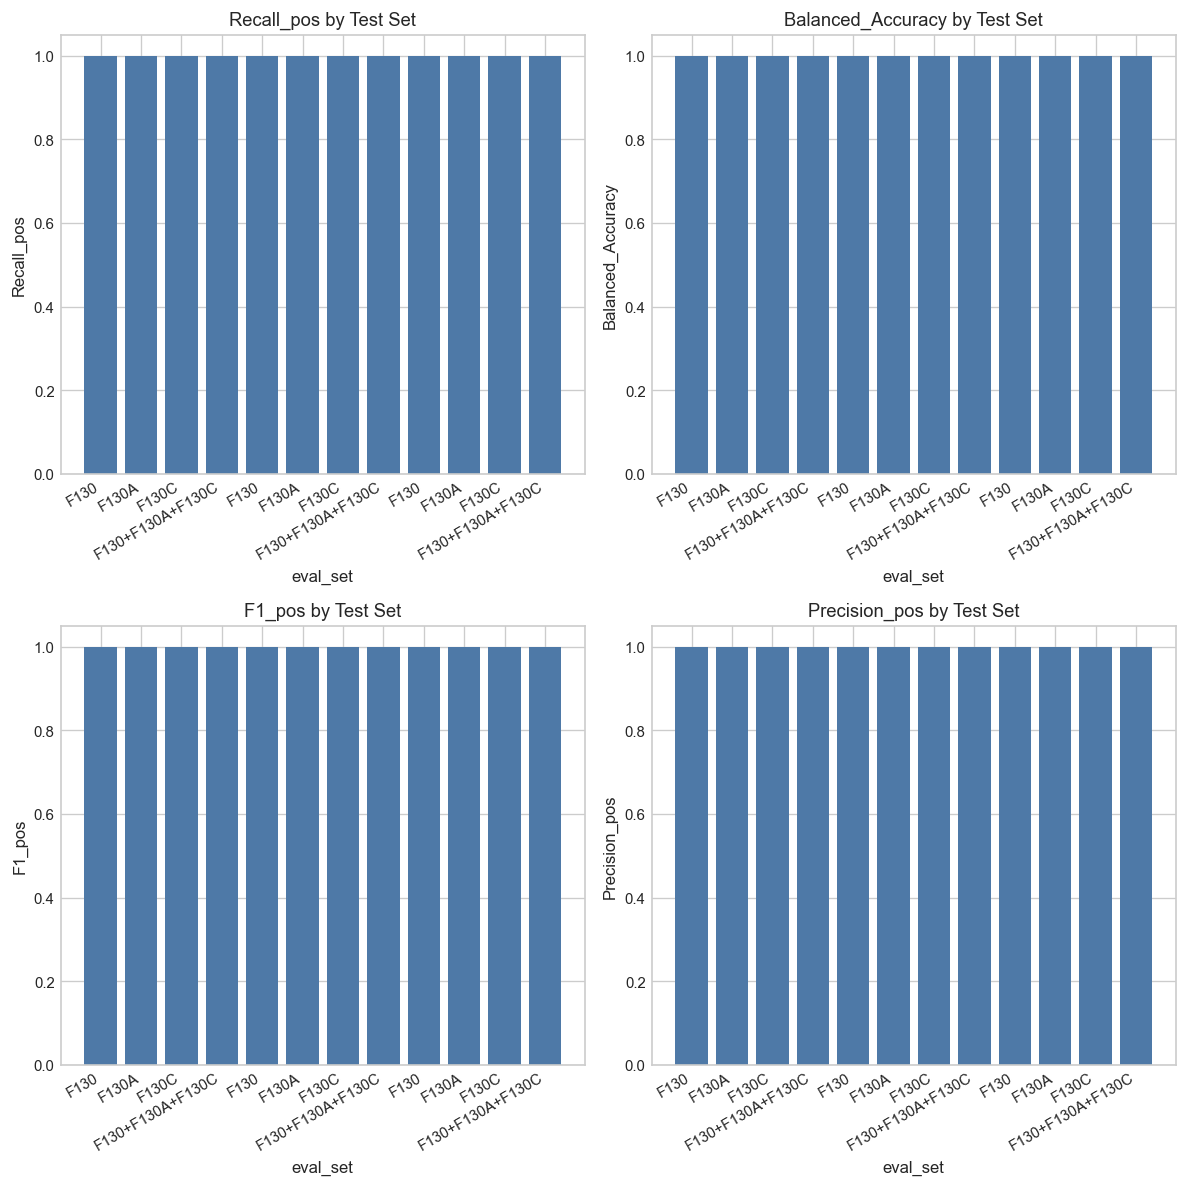

In [51]:
# Purpose: visualize per-group metrics with model-colored bars and legend.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_df = result_6['summary_df'].copy()

metric_map = [
    ('recall_pos', 'Recall_pos'),
    ('balanced_accuracy', 'Balanced_Accuracy'),
    ('f1_pos', 'F1_pos'),
    ('precision_pos', 'Precision_pos'),
]

label_col = 'eval_set' if 'eval_set' in plot_df.columns else ('test_domain' if 'test_domain' in plot_df.columns else None)
model_order = ['logistic_regression', 'rbf_svm', 'random_forest']

if not plot_df.empty and label_col is not None and 'model_name' in plot_df.columns:
    # index: test set, columns: model; each subplot keeps consistent colors by model and includes legend
    for ax, (col, title) in zip(axes.flatten(), metric_map):
        pv = plot_df.pivot_table(index=label_col, columns='model_name', values=col, aggfunc='mean')
        pv = pv.reindex(columns=[m for m in model_order if m in pv.columns])
        pv.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(f'{title} by Test Set')
        ax.set_xlabel(label_col)
        ax.set_ylabel(title)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=25)
        ax.legend(title='model', fontsize=8)
else:
    for ax in axes.flatten():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()



### 3.2.7 实验组 7（Experiment Group 7）

运行第 7 个实验配置（ExperimentSpec，spec index 6）。


In [52]:
# 目的（Purpose）: 运行实验组 7（Experiment Group 7），并展示按测试域（test domain）的汇总指标（summary metrics）。
# 输入（Inputs）: `experiment_specs`、`loaded_table`，以及第 1.1 节的全局参数。
# 输出（Outputs）: 生成 `result_7`；打印 spec 名称并展示 `summary_df`。
# 副作用（Side effects）: 会在 `output_root/spec_7.name/` 下写出产物（artifacts）；会训练模型，可能耗时。
# 说明（Notes / Assumptions）: 通常这是最后一组；建议在全部组完成后再运行第 4 节聚合（aggregation）。
spec_7 = experiment_specs[6]
result_7 = run_one_experiment(
    spec=spec_7,
    table=loaded_table,
    output_root=output_root,
    top_k_candidates=top_k_candidates,
    target_recall=target_recall,
    random_state=random_state,
    run_mode=run_mode,
    selected_features=features_by_spec[spec_7.name],
)
print(result_7['spec'].name)
display(result_7['summary_df'])





exp_07_train_F130_F130A_F130C


,n_samples,accuracy,balanced_accuracy,recall_pos,precision_pos,specificity_neg,f1_pos,auroc,fpr,tp,...,threshold,experiment,model_name,eval_set,eval_domains,train_domains,top_k,selected_feature_count,run_mode,feature_source
0,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,0.598741,exp_07_train_F130_F130A_F130C,logistic_regression,F130,F130,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features
1,2680.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1340.0,...,0.598741,exp_07_train_F130_F130A_F130C,logistic_regression,F130A,F130A,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features
2,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,0.598741,exp_07_train_F130_F130A_F130C,logistic_regression,F130C,F130C,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features
3,3158.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1579.0,...,0.598741,exp_07_train_F130_F130A_F130C,logistic_regression,F130+F130A+F130C,F130+F130A+F130C,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features
4,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,0.598741,exp_07_train_F130_F130A_F130C,rbf_svm,F130,F130,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features
5,2680.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1340.0,...,0.598741,exp_07_train_F130_F130A_F130C,rbf_svm,F130A,F130A,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features
6,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,0.598741,exp_07_train_F130_F130A_F130C,rbf_svm,F130C,F130C,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features
7,3158.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1579.0,...,0.598741,exp_07_train_F130_F130A_F130C,rbf_svm,F130+F130A+F130C,F130+F130A+F130C,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features
8,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,0.598741,exp_07_train_F130_F130A_F130C,random_forest,F130,F130,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features
9,2680.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1340.0,...,0.598741,exp_07_train_F130_F130A_F130C,random_forest,F130A,F130A,F130+F130A+F130C,None,5,gpu,section_2_4_selected_features


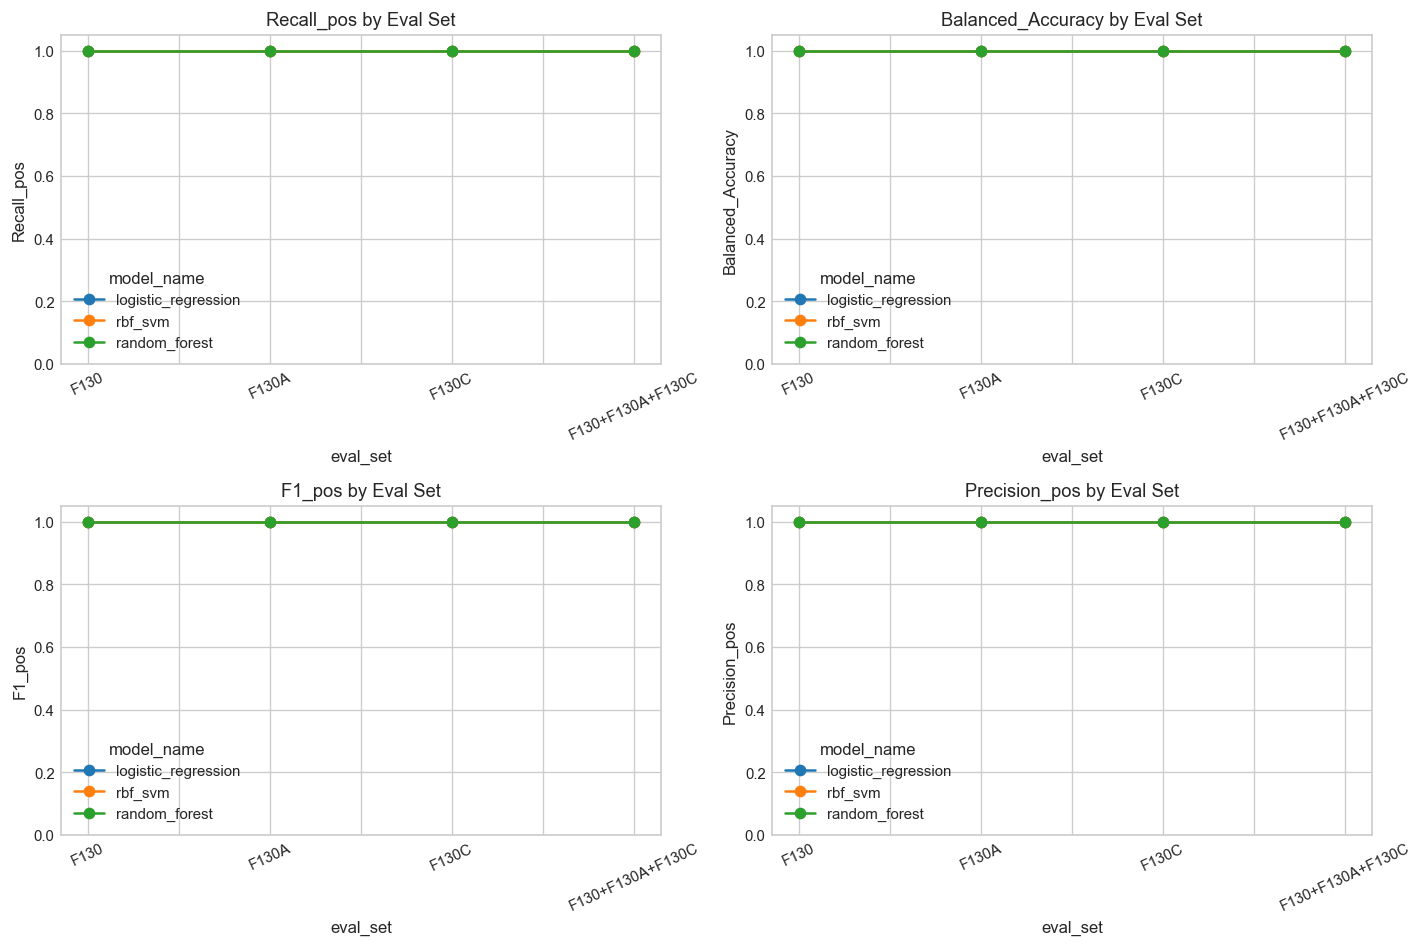

In [53]:
# Purpose: visualize 3-model results for experiment group 7 across 4 eval sets.
# Inputs: result_7['summary_df'].
# Outputs: a 2x2 panel for Recall/Balanced Accuracy/F1/Precision.
# Notes: x-axis is eval_set; each line is one model.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_df = result_7['summary_df'].copy()
metric_map = [
    ('recall_pos', 'Recall_pos'),
    ('balanced_accuracy', 'Balanced_Accuracy'),
    ('f1_pos', 'F1_pos'),
    ('precision_pos', 'Precision_pos'),
]
model_order = ['logistic_regression', 'rbf_svm', 'random_forest']
set_order = ['F130', 'F130A', 'F130C', 'F130+F130A+F130C']

if not plot_df.empty:
    for ax, (col, title) in zip(axes.flatten(), metric_map):
        pv = plot_df.pivot_table(index='eval_set', columns='model_name', values=col, aggfunc='mean')
        pv = pv.reindex(index=set_order).reindex(columns=model_order)
        pv.plot(ax=ax, marker='o')
        ax.set_title(f'{title} by Eval Set')
        ax.set_xlabel('eval_set')
        ax.set_ylabel(title)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=25)
else:
    for ax in axes.flatten():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()


## 3.3 Multi-Dimension Comparison (Model x Feature Vector)

After section 3.2 completes all 7 groups, this section compares:
- Model dimension (3 models): logistic_regression, rbf_svm, random_forest
- Feature-vector dimension (7 vectors): selected_features from the 7 groups

Outputs:
- comparison_model_feature_evalset.csv (long table)
- comparison_model_feature_evalset_pivot.csv (pivot table)
- plots for Recall and Balanced Accuracy on F130/F130A/F130C/combined eval sets



saved: E:\codes\ZZ-BK\outputs\model_test_cross_condition_260518-2\comparison_artifacts\comparison_model_feature_evalset.csv
saved: E:\codes\ZZ-BK\outputs\model_test_cross_condition_260518-2\comparison_artifacts\comparison_model_feature_evalset_pivot.csv


,n_samples,accuracy,balanced_accuracy,recall_pos,precision_pos,specificity_neg,f1_pos,auroc,fpr,tp,...,model_name,eval_set,eval_domains,train_domains,top_k,selected_feature_count,run_mode,feature_source,feature_vector_id,feature_count
0,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,logistic_regression,F130,F130,F130,None,5,gpu,section_2_4_selected_features,exp_01_train_F130,5
1,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,logistic_regression,F130,F130,F130A,None,5,gpu,section_2_4_selected_features,exp_02_train_F130A,5
2,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,logistic_regression,F130,F130,F130C,None,5,gpu,section_2_4_selected_features,exp_03_train_F130C,5
3,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,logistic_regression,F130,F130,F130+F130A,None,5,gpu,section_2_4_selected_features,exp_04_train_F130_F130A,5
4,218.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,109.0,...,logistic_regression,F130,F130,F130+F130C,None,5,gpu,section_2_4_selected_features,exp_05_train_F130_F130C,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,rbf_svm,F130C,F130C,F130C,None,5,gpu,section_2_4_selected_features,exp_03_train_F130C,5
80,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,rbf_svm,F130C,F130C,F130+F130A,None,5,gpu,section_2_4_selected_features,exp_04_train_F130_F130A,5
81,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,rbf_svm,F130C,F130C,F130+F130C,None,5,gpu,section_2_4_selected_features,exp_05_train_F130_F130C,5
82,260.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,130.0,...,rbf_svm,F130C,F130C,F130A+F130C,None,5,gpu,section_2_4_selected_features,exp_06_train_F130A_F130C,5


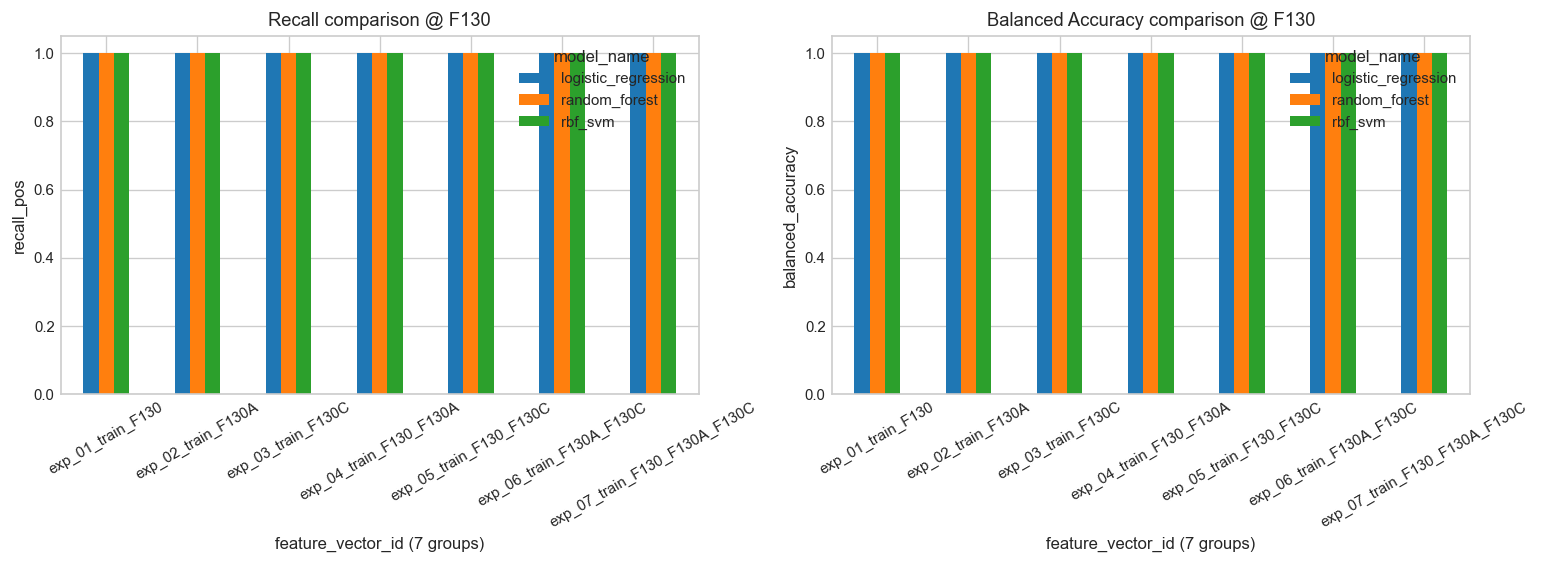

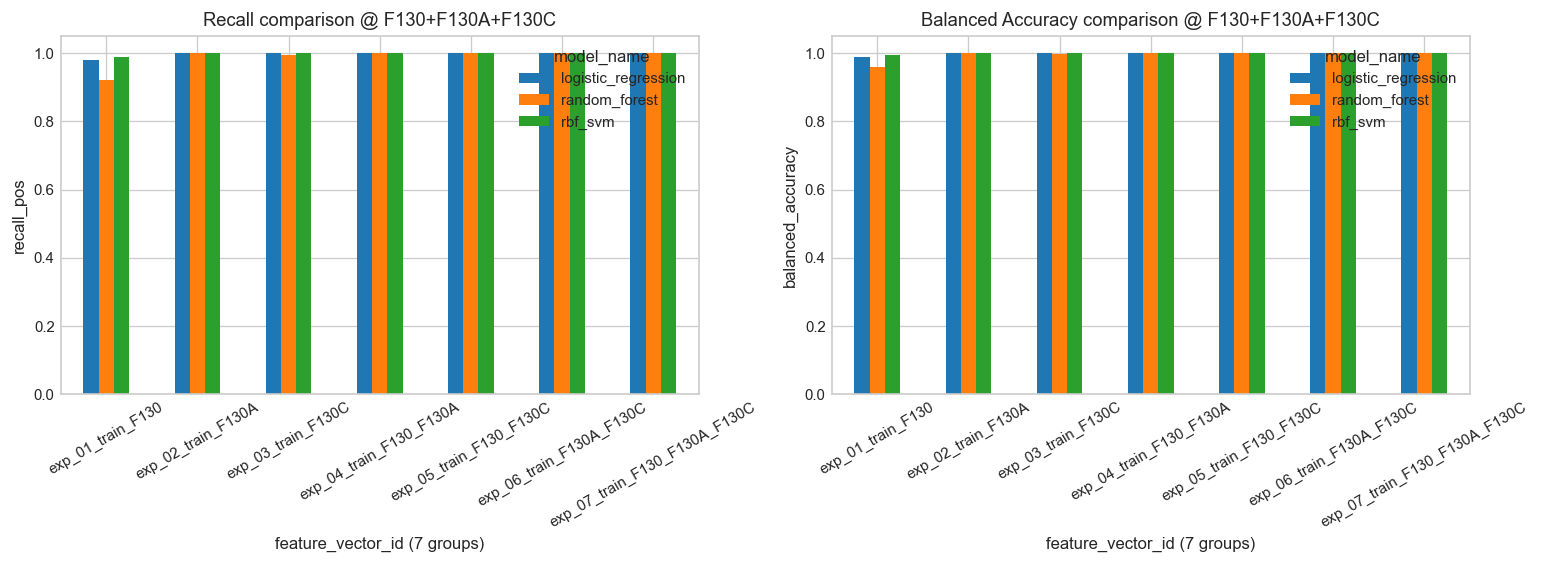

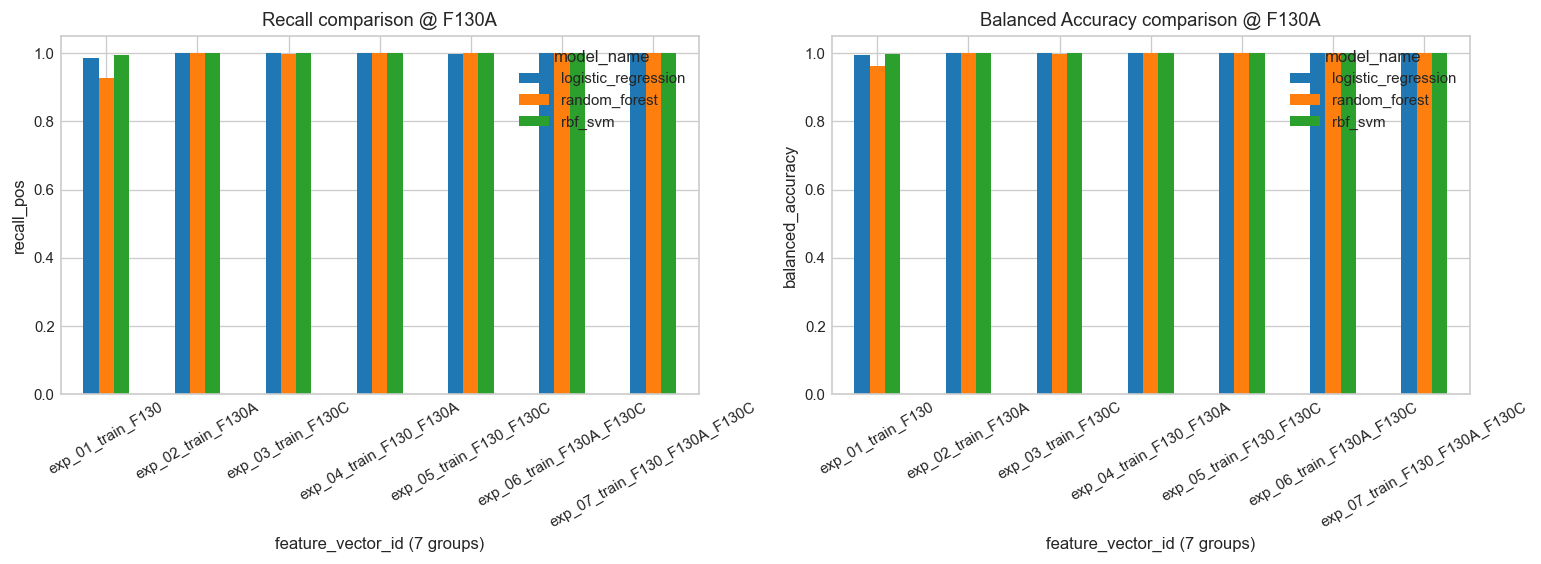

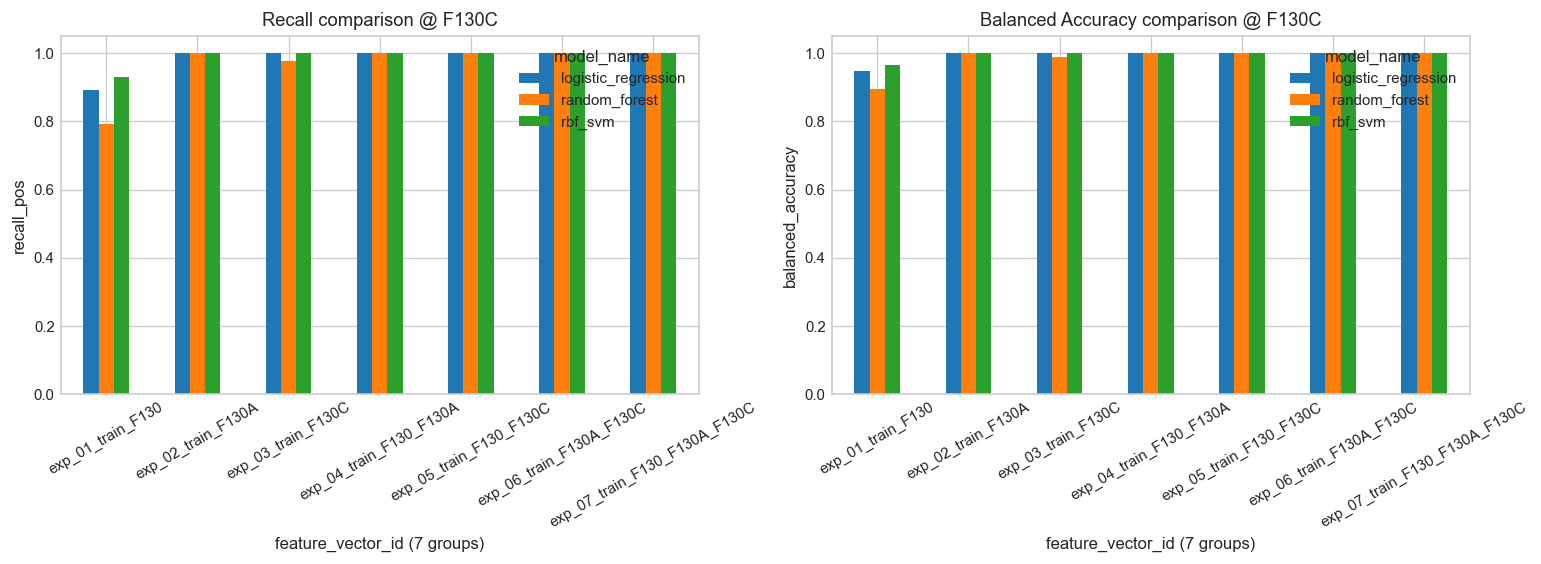

In [54]:
# Purpose: aggregate section 3.2 outputs and compare by model/feature-vector/eval-set dimensions.
# Inputs: result_1 ... result_7 (each summary_df contains 3 models x 4 eval sets).
# Outputs: comparison CSV files and plots.
all_results = [result_1, result_2, result_3, result_4, result_5, result_6, result_7]

rows = []
for r in all_results:
    spec_name = r['spec'].name
    feat_count = len(r.get('selected_features', []))
    df = r['summary_df'].copy()
    if df.empty:
        continue
    df['feature_vector_id'] = spec_name
    df['feature_count'] = feat_count
    rows.append(df)

if not rows:
    raise RuntimeError('No rows found from section 3.2; run all experiment-group cells first.')

comparison_df = pd.concat(rows, ignore_index=True)
comparison_df = comparison_df.sort_values(['eval_set', 'model_name', 'feature_vector_id']).reset_index(drop=True)

global_out = output_root / 'comparison_artifacts'
global_out.mkdir(parents=True, exist_ok=True)

comparison_csv = global_out / 'comparison_model_feature_evalset.csv'
comparison_df.to_csv(comparison_csv, index=False, encoding='utf-8-sig')

pivot_df = comparison_df.pivot_table(
    index=['eval_set', 'model_name'],
    columns='feature_vector_id',
    values=['recall_pos', 'balanced_accuracy', 'f1_pos', 'precision_pos'],
    aggfunc='mean'
)
pivot_df.to_csv(global_out / 'comparison_model_feature_evalset_pivot.csv', encoding='utf-8-sig')

print('saved:', comparison_csv)
print('saved:', global_out / 'comparison_model_feature_evalset_pivot.csv')
display(comparison_df)

# Plot 1: compare Recall across 7 feature vectors per eval_set
for eval_name, sub in comparison_df.groupby('eval_set', dropna=False):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    rec_pv = sub.pivot_table(index='feature_vector_id', columns='model_name', values='recall_pos', aggfunc='mean')
    bal_pv = sub.pivot_table(index='feature_vector_id', columns='model_name', values='balanced_accuracy', aggfunc='mean')

    rec_pv.plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'Recall comparison @ {eval_name}')
    axes[0].set_xlabel('feature_vector_id (7 groups)')
    axes[0].set_ylabel('recall_pos')
    axes[0].set_ylim(0, 1.05)
    axes[0].tick_params(axis='x', rotation=30)

    bal_pv.plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'Balanced Accuracy comparison @ {eval_name}')
    axes[1].set_xlabel('feature_vector_id (7 groups)')
    axes[1].set_ylabel('balanced_accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()




# 4. 聚合对比（Aggregated Comparison）

当 7 组实验都完成后，本节将合并结果并进行全局对比（global comparison）。

**目的（Purpose）**
- 将每组的按域汇总（per-group summaries）合并为一张总表，便于报告（reporting）。
- 通过图形对比不同训练域组合的泛化能力（generalization），并观察特征数敏感性（feature-count sensitivity）。

**输入（Inputs）**
- 第 3 节生成的 `result_1` ... `result_7`（每个来自 `run_one_experiment(...)`）。

**输出（Outputs）**
- 合并表 `summary_all` 与聚合对比图（aggregated plots）。


## 4.1 聚合结果可视化（Aggregated Result Visualization）

对 7 组实验做全局可视化对比（global visualization）。

**目的（Purpose）**
- 对比每个实验组在测试域上的平均指标（mean test-domain metrics）。
- 检查不同实验组偏好的特征数（feature count）范围是否不同（即特征数敏感性）。

**输出（Outputs）**
- 一张合并表 `summary_all`。
- 一张 1×2 面板图（panel figure）：
  - 左：按实验组的平均召回（Recall_pos）与平衡准确率（Balanced Accuracy）
  - 右：按实验组的“特征数 vs 召回”曲线（feature count vs recall curve）


In [ ]:
# 目的（Purpose）: 将各实验组的汇总表合并为一张聚合表（aggregated dataframe），用于 7 组结果的统一对比。
# 输入（Inputs）: 第 3.2 节产出的 `result_1` ... `result_7`。
# 输出（Outputs）: `summary_all`（包含全部测试域行），并补充辅助列 `experiment` 与 `best_top_k`。
# 副作用（Side effects）: 在 notebook 输出区展示聚合后的表格。
# 说明（Notes / Assumptions）: 假设当前内核（kernel session）中已存在全部 `result_i` 变量。
all_results = [result_1, result_2, result_3, result_4, result_5, result_6, result_7]
summary_tables = []
for item in all_results:
    tmp = item['summary_df'].copy()
    tmp['experiment'] = item['spec'].name
    tmp['best_top_k'] = item['best_top_k']
    summary_tables.append(tmp)

summary_all = pd.concat(summary_tables, ignore_index=True)
display(summary_all)




In [ ]:
# 目的（Purpose）: 绘制跨实验组的聚合对比，并展示特征数敏感性（feature-count sensitivity）。
# 输入（Inputs）: 上一单元格的 `summary_all`；以及 `all_results`（用于构造“特征数 vs 召回”曲线数据）。
# 输出（Outputs）: 一张 1×2 matplotlib 图：左为实验组层面的指标对比，右为“特征数 vs recall”曲线。
# 副作用（Side effects）: 在 notebook 输出区渲染图形。
# 说明（Notes / Assumptions）: 右图使用的是候选搜索阶段的 CV 召回（`cv_mean_recall_pos`），不是测试域召回（test-domain recall）。
# 详细说明（Detailed note）: 左图对比 7 组实验；右图用于观察特征数敏感性。
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

agg = summary_all.groupby('experiment', dropna=False)[['recall_pos', 'balanced_accuracy']].mean().reset_index()
axes[0].plot(agg['experiment'], agg['recall_pos'], marker='o', label='Recall_pos', color='#4472c4')
axes[0].plot(agg['experiment'], agg['balanced_accuracy'], marker='s', label='Balanced_Accuracy', color='#70ad47')
axes[0].set_title('7 experiments comparison')
axes[0].set_xlabel('experiment')
axes[0].set_ylabel('score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

feature_compare = pd.concat([r['candidate_df'].assign(experiment=r['spec'].name) for r in all_results], ignore_index=True)
for exp_name, sub in feature_compare.groupby('experiment', dropna=False):
    axes[1].plot(sub['selected_feature_count'], sub['cv_mean_recall_pos'], marker='o', label=exp_name)
axes[1].set_title('feature count vs recall')
axes[1].set_xlabel('selected_feature_count')
axes[1].set_ylabel('cv_mean_recall_pos')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()







# 5. 运行时间基准测试（Runtime Benchmark）

本节提供一个轻量级基准测试，用于对比 CPU 与 GPU 的运行时间（CPU vs GPU runtime）。

**目的（Purpose）**
- 在正式跑完 7 组实验之前，快速确认 GPU 加速（GPU acceleration）是否可用且是否有收益。
- 提前暴露 CUDA/XGBoost 安装问题，避免长时间运行后才失败。


## 5.1 CPU / GPU 基准测试（CPU / GPU Runtime Benchmark，建议先运行）

在一个训练域配置（training-domain setup）上做轻量计时（timing），对比 CPU 与 GPU 模式：
- CPU：`run_mode='cpu'`
- GPU：`run_mode='gpu'`（XGBoost 使用 CUDA）
建议在跑完整 7 组实验前，先用本节确认 `run_mode` 的可用性。

**说明（Notes）**
- 为了控制耗时，基准测试仅使用 `top_k_candidates` 的第一个值（Top-K）。
- 若 GPU 失败（`ok=False`），不影响后续用 CPU 模式继续完成整本 notebook。


In [ ]:
# 目的（Purpose）: 对同一流程做轻量 CPU vs GPU 运行时间基准测试（runtime benchmark），用于快速验证加速收益与环境可用性。
# 输入（Inputs）: 由 `selected_experiment_index` 选出的一个 `ExperimentSpec`、`loaded_table`、以及 `top_k_candidates[0]`。
# 输出（Outputs）: `benchmark_df`（包含各模式耗时与状态），并打印简要计时摘要（timing summary）。
# 副作用（Side effects）: 会分别在 cpu/gpu 下训练模型（两次），可能占用较多计算资源；并在输出区展示 dataframe。
# 说明（Notes / Assumptions）: GPU 模式需要支持 CUDA 的 XGBoost；失败信息会记录在 `error` 列，不会中断整本 notebook。
import time

def benchmark_run_mode(spec, table, top_k=60, random_state=42):
    """Benchmark CPU and GPU runtime under the same feature-selection workflow (CPU/GPU 基准测试).

    Summary
    - Runs Stage-A → RFECV → model search once under CPU and once under GPU using the same data and parameters.
    - Captures elapsed time and whether each run completed successfully.

    Args
    - spec: ExperimentSpec. Defines the training domains used to build the training mask.
    - table: LoadedFeatureTable. Merged feature table used by the experiment pipeline.
    - top_k: int. Stage-A candidate size used during the benchmark (keep small for speed).
    - random_state: int. Seed for reproducible benchmark behavior.

    Returns
    - pd.DataFrame with columns:
      - `mode`: 'cpu' or 'gpu'
      - `ok`: whether the full pipeline finished without exception
      - `seconds`: elapsed wall-clock seconds
      - `model_name`: selected model identifier (if ok)
      - `selected_feature_count`: number of selected features (if ok)
      - `error`: short error text (if not ok)

    Side Effects
    - Executes model training/search which may take time and use CPU/GPU resources.

    Notes
    - GPU failures usually indicate missing CUDA runtime, incompatible GPU driver, or non-CUDA XGBoost installation.
    """
    rows = []
    train_mask = (table.frame['split'] == 'train') & table.frame['base_domain'].isin(spec.train_domains)
    for mode in ['cpu', 'gpu']:
        t0 = time.perf_counter()
        ok = True
        err = ''
        model_name = ''
        selected_count = 0
        try:
            stage_a_scores = run_stage_a_filter(table=table, train_mask=train_mask, random_state=random_state)
            stage_a = slice_stage_a_scores(stage_a_scores, top_k=top_k)
            rfecv = run_rfecv_selection(table=table, train_mask=train_mask, candidate_features=stage_a.selected_features, random_state=random_state)
            model = search_best_model(table=table, train_mask=train_mask, selected_features=rfecv.selected_features, random_state=random_state, run_mode=mode)
            model_name = model.model_name
            selected_count = len(rfecv.selected_features)
        except Exception as ex:
            ok = False
            err = str(ex)[:300]
        dt = time.perf_counter() - t0
        rows.append({
            'mode': mode,
            'ok': ok,
            'seconds': round(dt, 3),
            'model_name': model_name,
            'selected_feature_count': selected_count,
            'error': err,
        })
    return pd.DataFrame(rows)

benchmark_spec = build_experiment_specs()[selected_experiment_index]
benchmark_df = benchmark_run_mode(benchmark_spec, loaded_table, top_k=top_k_candidates[0], random_state=random_state)
display(benchmark_df)
if benchmark_df['ok'].all():
    speed = benchmark_df.set_index('mode')['seconds'].to_dict()
    print(f"cpu={speed.get('cpu')}s, gpu={speed.get('gpu')}s")
else:
    print('GPU mode may be unavailable; please verify CUDA/XGBoost installation.')









# 6. 可复现性改造清单（Retrofit Checklist）

本节给出本 notebook 为提升可读性与可复现性（reproducibility）所做的最小改造清单。


## 6.1 最小改造清单（Minimal Retrofit Checklist，已应用）
1. 参数单元格包含：路径（paths）、Top-K（Top-K）、目标召回（target_recall）、随机种子（random_state）、运行模式（run_mode）。
2. 特征选择链路可调：阶段A（Stage-A）+ RFECV（RFECV）+ 特征数对比（feature-count comparison）。
3. 模型透明性：候选模型（candidates）/最优模型（best model）/阈值（threshold）等都会导出（export）。
4. CPU/GPU 基准测试（benchmark）在 7 组实验前提供快速验证。
5. 7 组输出按测试域拆分（per test domain），并在最终聚合对比中合并（merge）。

**说明（Note）**
- 本清单仅供说明，不影响运行逻辑。


# 7. 最终核对（Final Verification）

当你运行完主要单元格后，可使用本节检查输出产物是否齐全（artifact verification）。


## 7.1 最终输出核对清单（Final Output Checklist）

运行结束后，请核对以下文件（files）是否生成：

- `outputs/model_test_cross_condition_260506/summary_cross_condition.csv`
- 每个实验组目录下的 `selected_features.csv`
- `threshold.json`
- `metrics_*.json`
- `confusion_matrix_*.csv`

**说明（Notes）**
- 实际路径取决于第 1.1 节的 `output_root` 以及每组的 `spec.name`。
- 若某些 `metrics_<domain>.json` 缺失，通常表示该测试域（test domain）没有样本行，被自动跳过（skipped）。
